Projet Machine Learning

Partie 0 : Chargement des packages

In [311]:
%pip install pandas numpy requests pandas_datareader gdeltdoc scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [312]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


Partie 1 : Données sur les taux souverains
Cette partie nous a donné beaucoup de fil à retorde. En effet, afin de pratiquer le Machine Learning correctement, nous avions besoin d'un grand nombre de point. Ainsi, les séries quotiennes nous ont parru les plus pertinentes, car elles permettent d'avoir beaucoup de valeurs sans avoir une profondeur trop importante. 

1.1 Données sur les taux 10 Ans de la France et de l'Allemagne, calcul du spread et de la volatilité 
Source : 
    Pour la France : série "TEC10" : https://www.banque-france.fr/fr/statistiques/taux-et-cours/indices-obligataires-2026-03-02 
    Pour l'Allemagne : série "BBSSY.D.EUR.A615.000000WT1515.A" : https://www.bundesbank.de/en/statistics/money-and-capital-markets/interest-rates-and-yields/daily-yields-of-current-federal-securities-772220 

/var/folders/tz/ws4kjyfj6kvg6d6g1x_mjlgr0000gn/T/ipykernel_32597/1511626937.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  de["date"] = pd.to_datetime(de["date"], errors="coerce")


            fr_10y  de_10y  spread         delta  direction    vol_1m  \
date                                                                    
2004-11-03    3.97    3.91    0.06           NaN          0       NaN   
2004-11-04    3.93    3.87    0.06  0.000000e+00          0       NaN   
2004-11-05    3.91    3.85    0.06  0.000000e+00          0       NaN   
2004-11-08    3.96    3.90    0.06  0.000000e+00          0       NaN   
2004-11-09    3.95    3.89    0.06  0.000000e+00          0       NaN   
...            ...     ...     ...           ...        ...       ...   
2005-03-18    3.72    3.69    0.03  4.440892e-16          1  0.006530   
2005-03-21    3.76    3.73    0.03 -4.440892e-16          0  0.006530   
2005-03-22    3.74    3.70    0.04  1.000000e-02          1  0.006838   
2005-03-23    3.76    3.73    0.03 -1.000000e-02          0  0.007222   
2005-03-24    3.75    3.72    0.03  0.000000e+00          0  0.007222   

                  vol_1w  
date                   

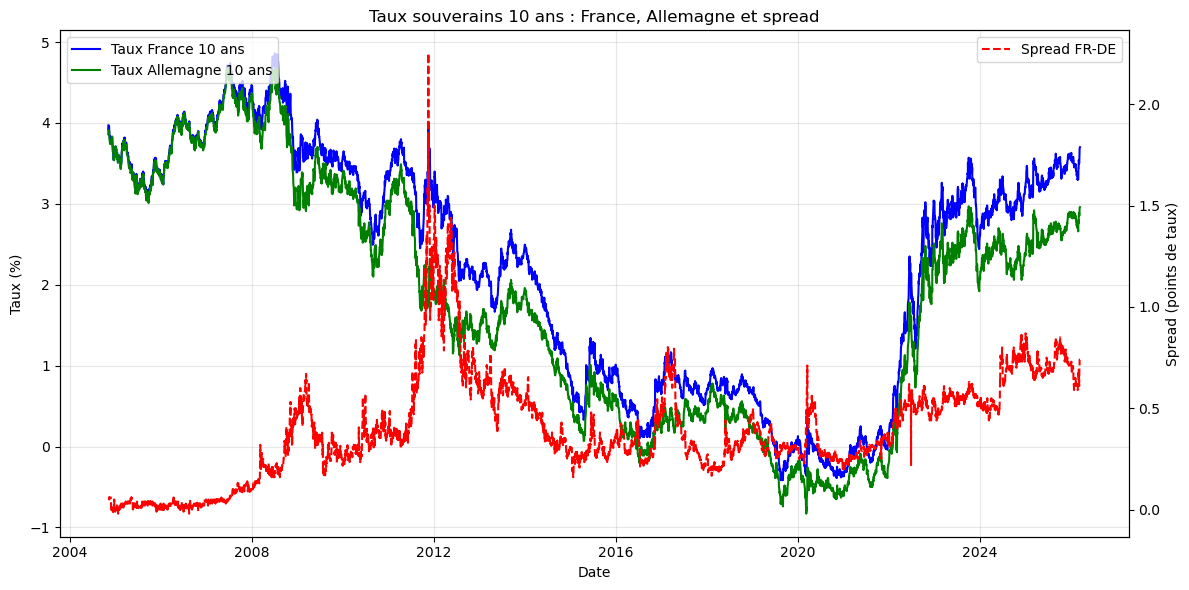

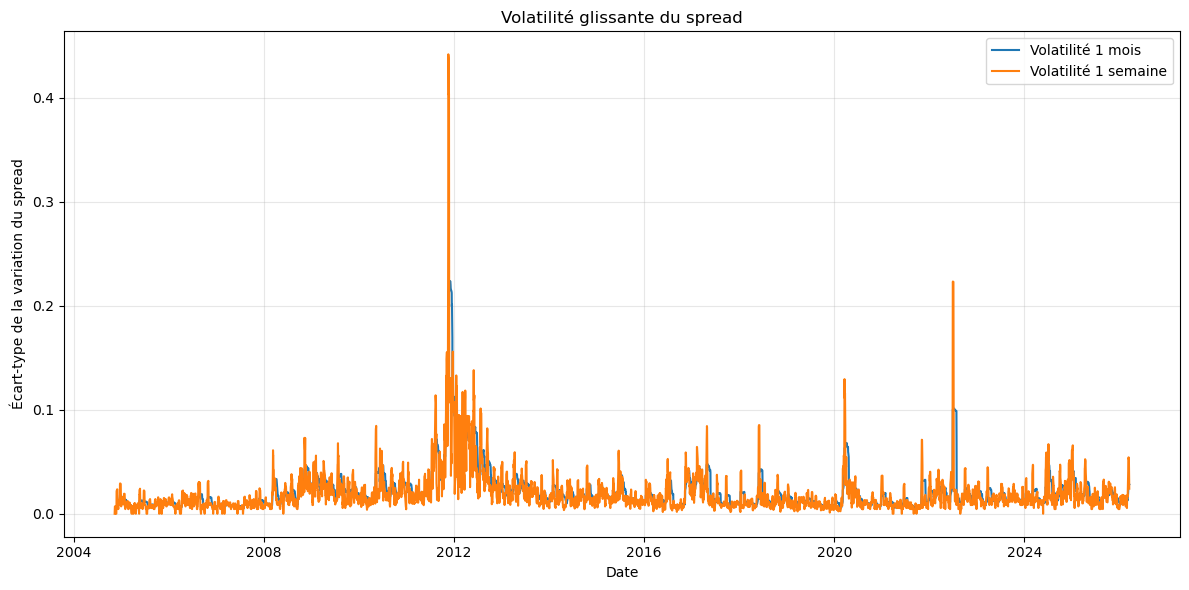

            spread  delta_w  direction_w
date                                    
2004-11-05    0.06      NaN            0
2004-11-12    0.06     0.00            0
2004-11-19    0.06     0.00            0
2004-11-26    0.00    -0.06            0
2004-12-03    0.00     0.00            0
2004-12-10    0.00     0.00            0
2004-12-17    0.01     0.01            1
2004-12-24    0.00    -0.01            0
2004-12-31    0.00     0.00            0
2005-01-07    0.01     0.01            1


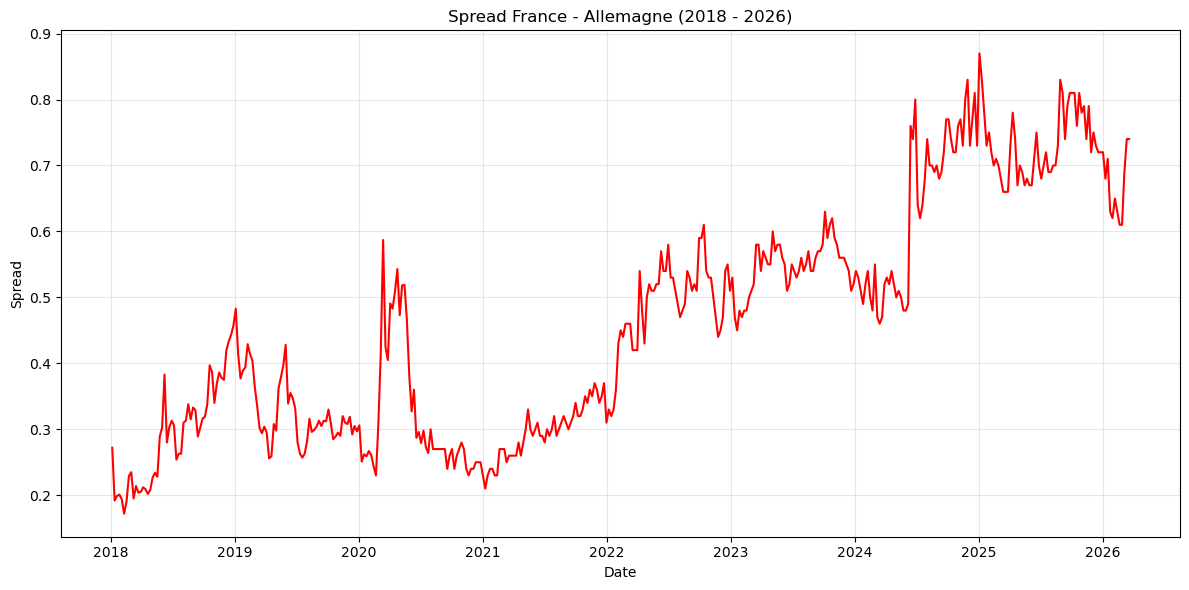

In [335]:
PATH_DATA = "../data/"

# -------------------------
# 1) France daily
# -------------------------
fr = pd.read_csv(
    PATH_DATA + "Webstat_Export_fr_5385693.csv",
    sep=";",
    skiprows=6,
    header=None
)

# on garde : date + colonne du 10 ans français
fr = fr.iloc[:, [0, 2]]
fr.columns = ["date", "fr_10y"]

fr["date"] = pd.to_datetime(fr["date"], errors="coerce")
fr["fr_10y"] = (
    fr["fr_10y"]
    .replace("-", pd.NA)
    .astype(str)
    .str.replace(",", ".", regex=False)
)
fr["fr_10y"] = pd.to_numeric(fr["fr_10y"], errors="coerce")

# -------------------------
# 2) Allemagne daily
# -------------------------
de = pd.read_csv(PATH_DATA + "BBSSY.D.REN.EUR.A630.000000WT1010.A.csv")

de = de.iloc[:, [0, 1]]
de.columns = ["date", "de_10y"]

de["date"] = pd.to_datetime(de["date"], errors="coerce")
de["de_10y"] = pd.to_numeric(de["de_10y"], errors="coerce")

# -------------------------
# 3) Merge + spread daily
# -------------------------
spread = pd.merge(fr, de, on="date", how="inner").sort_values("date")

spread["spread"] = spread["fr_10y"] - spread["de_10y"]

spread = spread.set_index("date")

spread.head()

# -------------------------
# 4) Delta et Volatilité
# -------------------------

spread = spread.dropna(subset=["spread"]) # Supprime les données manquantes, notamment WE et jours fériés

spread["delta"] = spread["spread"].diff()
spread["delta"] = spread["spread"].diff()
spread.head()

spread["direction"] = (spread["delta"] > 0).astype(int)
spread.head()

spread["vol_1m"] = spread["delta"].rolling(22).std() # sur un mois glissant
spread["vol_1w"] = spread["delta"].rolling(5).std() # sur une semaine (de bourse) glissante

# -------------------------
# 5) Visualisation et commentaires
# -------------------------

print(spread.head(100))
print(spread["direction"].value_counts(normalize=True)) # On constate 2 classes relativement équilibrées (55% de 0 contre 45% de 1)

# graphique 1 : Spread 
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(spread.index, spread["fr_10y"], label="Taux France 10 ans", color="blue")
ax1.plot(spread.index, spread["de_10y"], label="Taux Allemagne 10 ans", color="green")
ax1.set_xlabel("Date")
ax1.set_ylabel("Taux (%)")
ax1.set_title("Taux souverains 10 ans : France, Allemagne et spread")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(spread.index, spread["spread"], linestyle="--", label="Spread FR-DE", color="red")
ax2.set_ylabel("Spread (points de taux)")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()


#Graphique 2 : Vol
plt.figure(figsize=(12, 6))
plt.plot(spread.index, spread["vol_1m"], label="Volatilité 1 mois")
plt.plot(spread.index, spread["vol_1w"], label="Volatilité 1 semaine")
plt.title("Volatilité glissante du spread")
plt.xlabel("Date")
plt.ylabel("Écart-type de la variation du spread")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 6) Version hebdomadaire (vendredi)
# -------------------------

spread_weekly = spread.resample("W-FRI").last()

# delta hebdo
spread_weekly["delta_w"] = spread_weekly["spread"].diff()

# direction hebdo
spread_weekly["direction_w"] = (spread_weekly["delta_w"] > 0).astype(int)

# aperçu
print(spread_weekly[["spread", "delta_w", "direction_w"]].head(10))

spread_w_2018_2026 = spread_weekly.loc["2018":"2026"]

plt.figure(figsize=(12, 6))
plt.plot(spread_w_2018_2026.index, spread_w_2018_2026["spread"], color="red")

plt.title("Spread France - Allemagne (2018 - 2026)")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Partie 2 : Données relatives aux News et regression sur les spreads
Nous avons exploré différentes sources, en français ou en anglais, avec des profondeurs plus ou moins grandes et des précisions plus ou moins importantes. 
Plusieurs obstacles se sont dressés contre nous : d'abord, la plupart des bases sont payantes, ou alors ne permettent pas d'avoir suffisament de points pour faire du ML. De plus, comme vous allez le voir, les résultats sont malheureusement très peu significatifs. Nous avons testé un grand nombre d'outils et de set de données, en obtenant des resultats très peu probants, surement car la relation que l'on cherche à démontrer n'existe pas, ou est systématiquement pollué par les bruits de marché. 
Néanmois, nous nous sommes attachés à décrire les outils de ML utilisés et les résultats obtenus, même si ceci sont décevants sur le plan conceptuel. 

2.1 Reuters 
L'agence de presse nous permet d'exploiter les titres et une brève description de ses dépêches. 
Gratuitement, nous n'avons pu récupéré que les données de 2018 à 2020 

2.1.1 Chargement des données

In [ ]:
# -------------------------
# 1) Chargement des données
# -------------------------
news_reuters_df = pd.read_csv("../data/reuters_headlines.csv")
news_reuters_df["Time"] = pd.to_datetime(news_reuters_df["Time"], errors="coerce")
min_date = news_reuters_df["Time"].min()
max_date = news_reuters_df["Time"].max()
print(f"Sample : {min_date.date()} - {max_date.date()}")
print(news_reuters_df.columns)
news_reuters_df.head()

Sample : 2018-03-20 - 2020-07-18
Index(['Headlines', 'Time', 'Description'], dtype='object')


,Headlines,Time,Description
0,TikTok considers London and other locations fo...,2020-07-18,TikTok has been in discussions with the UK gov...
1,Disney cuts ad spending on Facebook amid growi...,2020-07-18,Walt Disney has become the latest company to ...
2,Trail of missing Wirecard executive leads to B...,2020-07-18,Former Wirecard chief operating officer Jan M...
3,Twitter says attackers downloaded data from up...,2020-07-18,Twitter Inc said on Saturday that hackers were...
4,U.S. Republicans seek liability protections as...,2020-07-17,A battle in the U.S. Congress over a new coron...


2.1.2 Construction des features et visualisation

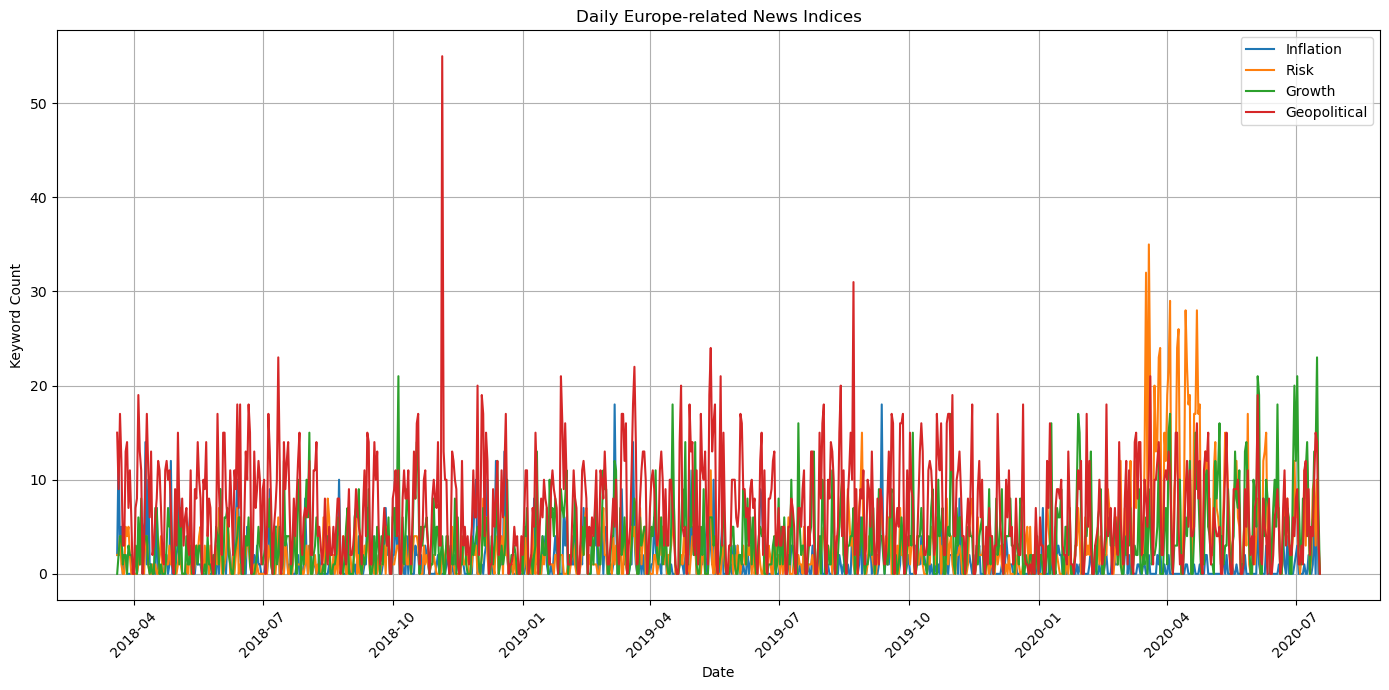

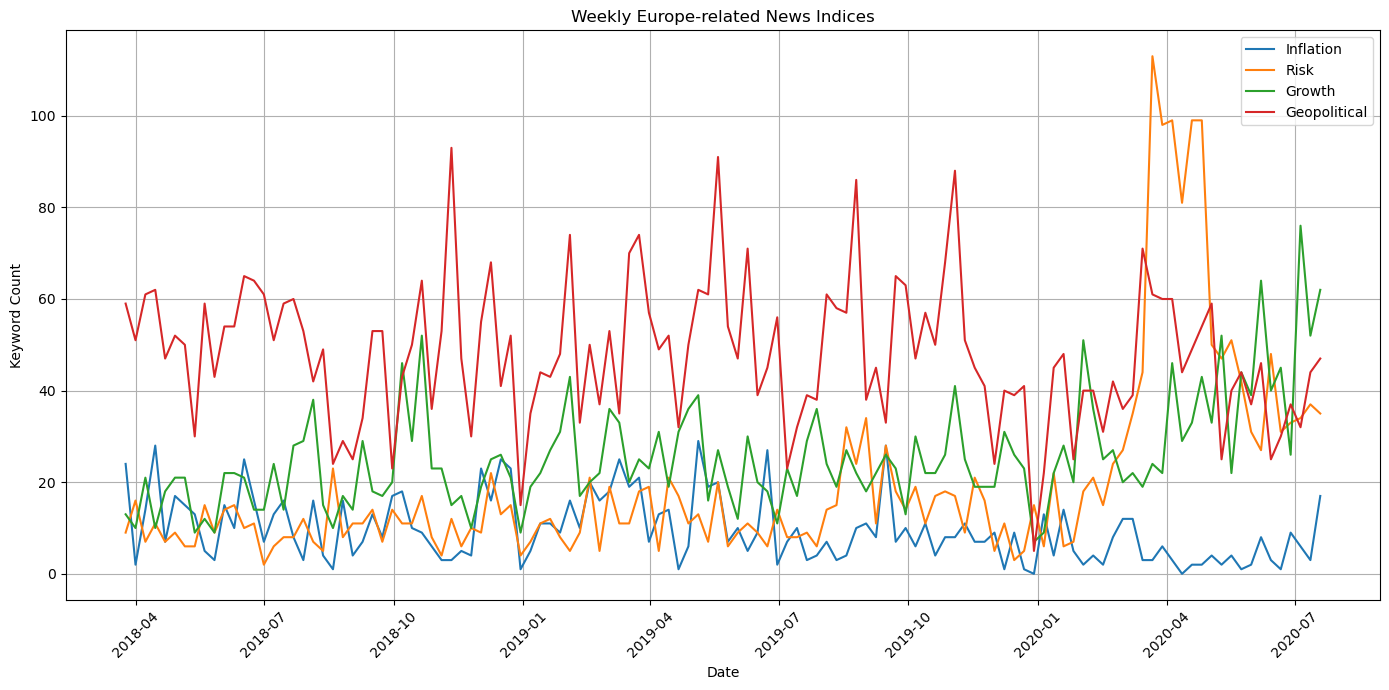

In [330]:
# -------------------------
# 2) Construction des features
# -------------------------

import re

# Construire le texte complet
news_reuters_df["text"] = (
    news_reuters_df["Headlines"].fillna("") + " " +
    news_reuters_df["Description"].fillna("")
)

news_reuters_df["text"] = news_reuters_df["text"].str.lower()

# Convertir la date/heure
news_reuters_df["Time"] = pd.to_datetime(news_reuters_df["Time"], errors="coerce")

# Date journalière compatible avec le spread
news_reuters_df["date"] = news_reuters_df["Time"].dt.normalize()

news_reuters_df["date"].min(), news_reuters_df["date"].max()

# --------------------------------------------------
# Listes de mots-clés macro
# --------------------------------------------------
inflation_words = [
    "inflation", "price pressure", "cpi", "hike",
    "rate increase", "monetary policy", "hawkish",
    "dovish", "tightening", "ecb"
]

risk_words = [
    "crisis", "recession", "debt", "deficit",
    "default", "downgrade", "risk premium",
    "volatility", "instability"
]

growth_words = [
    "recovery", "expansion", "gdp", "growth",
    "unemployment", "employment"
]

geopolitical_words = [
    "war", "conflict", "energy shock",
    "gas", "sanctions"
]

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

news_reuters_df["macro_inflation_index"] = news_reuters_df["text"].apply(
    lambda x: count_keywords(x, inflation_words)
)

news_reuters_df["macro_risk_index"] = news_reuters_df["text"].apply(
    lambda x: count_keywords(x, risk_words)
)

news_reuters_df["growth_index"] = news_reuters_df["text"].apply(
    lambda x: count_keywords(x, growth_words)
)

news_reuters_df["geopolitical_index"] = news_reuters_df["text"].apply(
    lambda x: count_keywords(x, geopolitical_words)
)

# --------------------------------------------------
# Agrégation journalière
# --------------------------------------------------
daily_reuters_indices = news_reuters_df.groupby("date", as_index=False)[[
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]].sum()

daily_reuters_indices.head()

plt.figure(figsize=(14, 7))

plt.plot(daily_reuters_indices["date"], daily_reuters_indices["macro_inflation_index"], label="Inflation")
plt.plot(daily_reuters_indices["date"], daily_reuters_indices["macro_risk_index"], label="Risk")
plt.plot(daily_reuters_indices["date"], daily_reuters_indices["growth_index"], label="Growth")
plt.plot(daily_reuters_indices["date"], daily_reuters_indices["geopolitical_index"], label="Geopolitical")

plt.title("Daily Europe-related News Indices")
plt.xlabel("Date")
plt.ylabel("Keyword Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Agrégation hebdomadaire
# --------------------------------------------------

daily_reuters_indices["date"] = pd.to_datetime(daily_reuters_indices["date"])
daily_reuters_indices = daily_reuters_indices.set_index("date")
weekly_reuters_indices = daily_reuters_indices.resample("W").sum()

plt.figure(figsize=(14, 7))

plt.plot(weekly_reuters_indices.index, weekly_reuters_indices["macro_inflation_index"], label="Inflation")
plt.plot(weekly_reuters_indices.index, weekly_reuters_indices["macro_risk_index"], label="Risk")
plt.plot(weekly_reuters_indices.index, weekly_reuters_indices["growth_index"], label="Growth")
plt.plot(weekly_reuters_indices.index, weekly_reuters_indices["geopolitical_index"], label="Geopolitical")

plt.title("Weekly Europe-related News Indices")
plt.xlabel("Date")
plt.ylabel("Keyword Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


2.1.3 Test de différents modèles

Random Forest
              precision    recall  f1-score   support

           0       0.53      0.64      0.58        64
           1       0.42      0.32      0.37        53

    accuracy                           0.50       117
   macro avg       0.48      0.48      0.47       117
weighted avg       0.48      0.50      0.48       117

geopolitical_index       0.332063
growth_index             0.268565
macro_inflation_index    0.201907
macro_risk_index         0.197465
dtype: float64


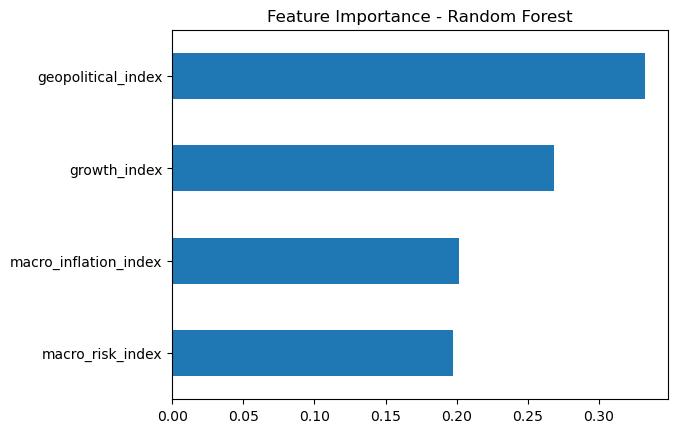

In [341]:
# =========================================================
# 1. MERGE DES DONNEES (SPREAD + FEATURES NEWS)
# =========================================================

# On fusionne la direction du spread avec les indices news
data_reuters_final = spread[["direction"]].merge(
    daily_reuters_indices,
    left_index=True,
    right_index=True,
    how="inner"
)

# =========================================================
# 2. PREPARATION DES VARIABLES X ET y
# =========================================================

features = [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]

X = data_reuters_final[features]
y = data_reuters_final["direction"]

# =========================================================
# 3. TRAIN / TEST SPLIT (TEMPOREL)
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# =========================================================
# 4. MODELE RANDOM FOREST
# =========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred))

# =========================================================
# 5. IMPORTANCE DES FEATURES
# =========================================================

importance = pd.Series(
    model.feature_importances_,
    index=features)

print(importance.sort_values(ascending=False))

# =========================================================
# 6. VISUALISATION DES IMPORTANCES
# =========================================================

plt.figure()
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.show()



La matrice de confusion montre des résultats très mauvais pour ce modèle RandomForest associé à ce jeu de données. 
L'accuracy vaut 50% en moyenne, ce qui traduit le fait que le modèle à le même pouvoir prédictif qu'une pièce de monnaie : beaucoup d'énergie pour si peu !
On note également que le modèle prédit plus correctement les baisses, peut-être parce que celle-ci sont moins bruitées... 

Logistic Regression
              precision    recall  f1-score   support

           0       0.57      0.61      0.59        64
           1       0.49      0.45      0.47        53

    accuracy                           0.54       117
   macro avg       0.53      0.53      0.53       117
weighted avg       0.54      0.54      0.54       117

CV scores: [0.48453608 0.57731959 0.50515464 0.45360825 0.56701031]
Mean accuracy: 0.5175257731958762


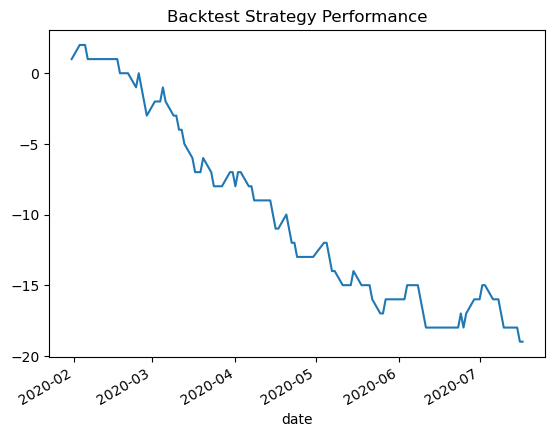

AUC: 0.5173938679245282


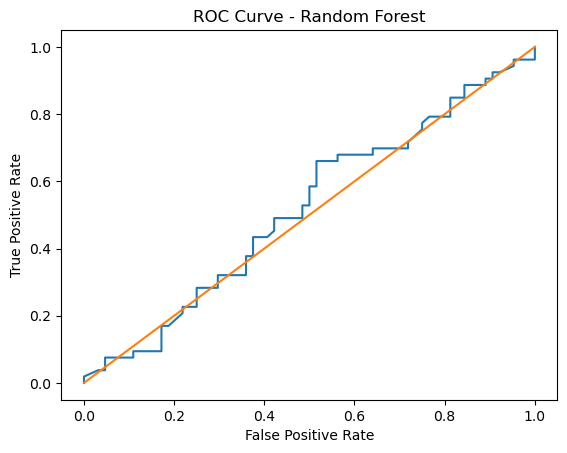

Baseline accuracy: 0.5470085470085471
Model accuracy: 0.49572649572649574


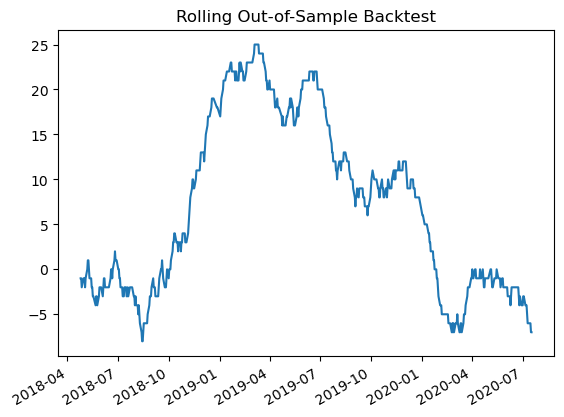

In [ ]:
# =========================================================
# 7. MODELE LOGISTIC REGRESSION (BASELINE LINEAIRE)
# =========================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

# =========================================================
# 8. CROSS-VALIDATION TIME SERIES
# =========================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=tscv)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

# =========================================================
# 9. BACKTEST SIMPLE
# =========================================================

backtest = data_reuters_final.iloc[len(X_train):].copy()
backtest["pred"] = y_pred

backtest["strategy_return"] = (
    (backtest["pred"] * 2 - 1) * data_reuters_final.loc[backtest.index, "direction"]
)

backtest["cum_return"] = backtest["strategy_return"].cumsum()

plt.figure()
backtest["cum_return"].plot()
plt.title("Backtest Strategy Performance")
plt.show()

# =========================================================
# 10. ROC CURVE + AUC
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_proba)
print("AUC:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# =========================================================
# 11. BASELINE NAIF
# =========================================================

from sklearn.metrics import accuracy_score

y_baseline = np.zeros_like(y_test)

baseline_accuracy = accuracy_score(y_test, y_baseline)
model_accuracy = accuracy_score(y_test, y_pred)

print("Baseline accuracy:", baseline_accuracy)
print("Model accuracy:", model_accuracy)

# =========================================================
# 12. ROLLING OUT-OF-SAMPLE BACKTEST
# =========================================================

rolling_preds = []
rolling_real = []
rolling_dates = []

window_size = 24

for i in range(window_size, len(X)):
    
    X_train_roll = X.iloc[i-window_size:i]
    y_train_roll = y.iloc[i-window_size:i]
    
    X_test_roll = X.iloc[i:i+1]
    y_test_roll = y.iloc[i:i+1]
    
    model_roll = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    
    model_roll.fit(X_train_roll, y_train_roll)
    
    pred = model_roll.predict(X_test_roll)
    
    rolling_preds.append(pred[0])
    rolling_real.append(y_test_roll.values[0])
    rolling_dates.append(X.index[i])

rolling_df = pd.DataFrame({
    "real": rolling_real,
    "pred": rolling_preds
}, index=rolling_dates)

rolling_df["strategy_return"] = (
    (rolling_df["pred"] * 2 - 1) * rolling_df["real"]
)

rolling_df["cum_return"] = rolling_df["strategy_return"].cumsum()

plt.figure()
rolling_df["cum_return"].plot()
plt.title("Rolling Out-of-Sample Backtest")
plt.show()

Le modèle 

1.2.2 Les Echos
L'idée est ici de récupérer uniquement les news françaises, d'un quotien spécialisé en économie et en finance

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from urllib.parse import urljoin

BASE_URL = "https://www.lesechos.fr"
PAGE_URL = "https://www.lesechos.fr/"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

def get_html(url):
    r = requests.get(url, headers=HEADERS, timeout=15)
    r.raise_for_status()
    return r.text

def parse_articles(html, base_url=BASE_URL):
    soup = BeautifulSoup(html, "html.parser")
    rows = []

    # Essaie de repérer les balises article
    for article in soup.select("article"):
        title = None
        url = None
        date = None

        # lien + titre
        a = article.find("a", href=True)
        if a:
            url = urljoin(base_url, a["href"])

        # plusieurs options possibles pour le titre
        for selector in ["h1", "h2", "h3"]:
            tag = article.find(selector)
            if tag and tag.get_text(strip=True):
                title = tag.get_text(strip=True)
                break

        # balise time si présente
        time_tag = article.find("time")
        if time_tag:
            date = time_tag.get("datetime") or time_tag.get_text(strip=True)

        if title and url:
            rows.append({
                "title": title,
                "date": date,
                "url": url
            })

    return rows

def scrape_page(url):
    html = get_html(url)
    data = parse_articles(html)
    df = pd.DataFrame(data).drop_duplicates()
    return df

if __name__ == "__main__":
    df = scrape_page(PAGE_URL)
    print(df.head(10))
    df.to_csv("news_metadata.csv", index=False, encoding="utf-8-sig")
    print(f"{len(df)} articles sauvegardés dans news_metadata.csv")


# Cette méthode était prometteuse sur le papier, mais elle se heurte à la pratique car le site web du journal empêche le webscrapping, 
# donc les requêtes sont rapidement rejetées. 

                                               title  date  \
0  Iran : la troisième guerre du Golfe toujours s...  None   
1  SpaceX sur la rampe de lancement pour une intr...  None   
2  Guerre au Moyen-Orient : L'armée israélienne v...  None   
3               Philippe - Attal : faites vos jeux !  None   
4  Les leçons du chef d'état-major de la marine f...  None   
5  « Nous n'avions pas prévu une guerre de cette ...  None   
6  « Avec mon bac moins 1, je dirige la plus gros...  None   
7  La fin d'une saga familiale catalane ? Après p...  None   
8                 Bruno Le Maire, la vie après Bercy  None   
9  D'une thèse sur les franchises à un géant mond...  None   

                                                 url  
0  https://www.lesechos.fr/monde/etats-unis/iran-...  
1  https://www.lesechos.fr/finance-marches/marche...  
2  https://www.lesechos.fr/monde/afrique-moyen-or...  
3  https://www.lesechos.fr/politique-societe/poli...  
4  https://www.lesechos.fr/industrie-servi

1.2.3 Le Monde
Nous avons également tenté d'utiliser le flux RSS du Monde

In [ ]:
import feedparser
import pandas as pd

feed_url = "https://www.lemonde.fr/economie/rss_full.xml"
feed = feedparser.parse(feed_url)

rows = []
for entry in feed.entries:
    rows.append({
        "title": entry.get("title"),
        "published_at": entry.get("published"),
        "url": entry.get("link"),
        "summary": entry.get("summary")
    })

df = pd.DataFrame(rows)
print(df.head(25))

# Cependant, on ne peut avoir accès (gratuitement) qu'au 20 derniers articles


                                                title  \
0   Comment les médias couvrent la guerre au Moyen...   
1   Au Canada, le télétravail des fonctionnaires r...   
2   Des villages de la Mayenne se tournent vers le...   
3   Jensen Huang, patron de Nvidia, l’anti-doomer ...   
4   La ville de Fresnes s’interroge après le sacca...   
5   « Dans six mois, on met la clé sous la porte »...   
6   Emmanuel Grégoire intronisé à la Mairie de Par...   
7   Guerre au Moyen-Orient : le mois qui a plongé ...   
8   Immobilier : qui sont les loueurs en meublé no...   
9   Banque populaire Caisse d’épargne veut faire d...   
10  KitKat : après un vol d’une cargaison de 12 to...   
11  « L’essor des marchés de prédiction attire dés...   
12  Un jour à Montargis : sans voiture, point de s...   
13  Hausse des prix du carburant : au sud de Lyon,...   
14  La Bretagne, bastion d’une industrie agroalime...   
15  A Marseille, Benoît Payan installe sa majorité...   
16  Meredith Whittaker, préside

1.2.4 GDELT
Ce projet permet, dans le cadre d'un usage strictement privé, de webscapper un très grand nombre de titres de journaux, anglophones mais aussi internationaux (alors traduits en anglais). 2 niveaux de granularités sont proposés : toutes les 15 minutes, ou tous les jours. Nous avons choisi cette deuxième option puisque nous n'avons pas de données sur les spread intra-day. 
Le point négatif de cette méthode est d'une part la profondeur (limité quand on remonte dans le temps) et le temps pour récupérer les données. A titre d'information, pour récupérer les articles entre 2023 et 2024, il fallut plus de 300 minutes, soit 5 heures.

In [ ]:
# import pandas as pd
# from datetime import datetime, timedelta

# # pip install gdeltdoc
# from gdeltdoc import GdeltDoc, Filters

# START_DATE = "2023-01-01"
# END_DATE   = "2026-03-28"

# gd = GdeltDoc()

# def date_range(start_date: str, end_date: str):
#     start = datetime.strptime(start_date, "%Y-%m-%d")
#     end = datetime.strptime(end_date, "%Y-%m-%d")
#     cur = start
#     while cur <= end:
#         yield cur
#         cur += timedelta(days=1)

# all_days = []

# for day in date_range(START_DATE, END_DATE):
#     time.sleep(6)
#     day_str = day.strftime("%Y-%m-%d")
#     next_day_str = (day + timedelta(days=1)).strftime("%Y-%m-%d")

#     try:
#         filters = Filters(
#             start_date=day_str,
#             end_date=next_day_str,
#             language="French"
#         )

#         articles = gd.article_search(filters)

#         if articles is None or len(articles) == 0:
#             print(f"{day_str} -> 0 article")
#             continue

#         articles["query_date"] = pd.to_datetime(day_str)
#         all_days.append(articles)

#         print(f"{day_str} -> {len(articles)} articles")

#     except Exception as e:
#         print(f"Erreur {day_str}: {e}")

# news_df = pd.concat(all_days, ignore_index=True) if all_days else pd.DataFrame()

# if not news_df.empty:
#     # nettoyage minimal
#     news_df["seendate"] = pd.to_datetime(news_df["seendate"], errors="coerce")
#     news_df["day"] = news_df["seendate"].dt.date

#     # garder seulement les colonnes utiles
#     cols = ["day", "seendate", "title", "url", "domain", "language", "sourcecountry"]
#     cols = [c for c in cols if c in news_df.columns]
#     news_df = news_df[cols].drop_duplicates()

# news_df.to_csv("gdelt_french_titles_2023_2026.csv", index=False, encoding="utf-8-sig")

# print(news_df.head())
# print(news_df.shape)

# daily_titles = (
#     news_df.groupby("day")
#     .agg(
#         n_articles=("title", "count"),
#         titles=("title", lambda x: " ||| ".join(x.dropna().astype(str)))
#     )
#     .reset_index()
# )

# daily_titles.to_csv("gdelt_french_titles_daily_2023_2026.csv", index=False, encoding="utf-8-sig")

# print(daily_titles.head())
# print(daily_titles.shape)

In [ ]:
daily_titles_gdelt = pd.read_csv("gdelt_french_titles_daily_2023_2026.csv")
daily_titles_gdelt.head(10)
# Dans la colonne titles, on trouve à la suite tous les titres chargés. 
# Les dates ne sont pas très regulières au début de l'échantillon, sans préjudice sur leur analyse

,day,n_articles,titles
0,2023-01-06,249,Boire un seul soda par jour peut augmenter le ...
1,2023-01-07,1,Brésil : le palais présidentiel en mauvais éta...
2,2023-01-14,245,Élection au Brésil : révélations compromettant...
3,2023-01-15,237,Paris et Berlin appellent lAfrique à condamner...
4,2023-01-16,13,LIran va bientôt recevoir des chasseurs russes...
5,2023-01-19,236,Chine : les transactions sur le marché des dev...
6,2023-01-20,14,Les pays occidentaux cherchent à freiner le dé...
7,2023-01-28,245,On a tout essayé : Guillaume Canet balance ...
8,2023-01-29,5,Le président français salue le rôle et le dyna...
9,2023-02-02,241,Miou - Miou mineure mais en couple avec Coluch...


AUC = 0.5137310606060607

Importance des features :
              feature  importance
5              vol_1m    0.205980
0     inflation_index    0.190528
4         news_volume    0.170584
3  geopolitical_index    0.163792
2        growth_index    0.140379
1          risk_index    0.128736


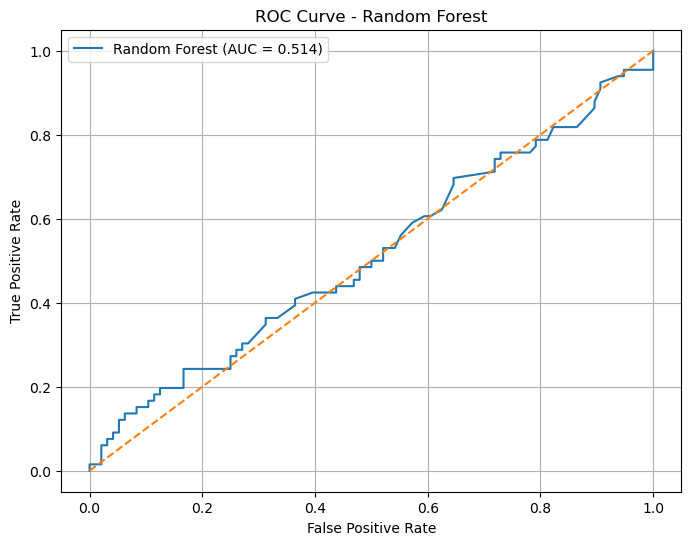


Colonnes de data_final_europe :
['date', 'fr_10y', 'de_10y', 'spread', 'inflation_index', 'risk_index', 'growth_index', 'geopolitical_index', 'news_volume', 'delta', 'direction_t+1', 'vol_1m']

Aperçu :
        date  fr_10y  de_10y  spread  inflation_index  risk_index  \
4 2023-01-06    2.85    2.32    0.53         0.000000    0.000000   
5 2023-01-09    2.80    2.27    0.53         0.048193    0.032129   
6 2023-01-10    2.79    2.27    0.52         0.000000    0.000000   
7 2023-01-11    2.73    2.27    0.46         0.000000    0.000000   
8 2023-01-12    2.66    2.19    0.47         0.000000    0.000000   

   growth_index  geopolitical_index  news_volume         delta  direction_t+1  \
4       0.00000            0.000000          0.0  2.000000e-02            0.0   
5       0.02008            0.116466        249.0 -4.440892e-16            0.0   
6       0.00000            0.000000          0.0 -1.000000e-02            0.0   
7       0.00000            0.000000          0.0 -6.00000

In [340]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# =========================================================
# 1. PREPARATION DES DONNEES NEWS
# =========================================================

daily_titles_gdelt["day"] = pd.to_datetime(daily_titles_gdelt["day"], errors="coerce")
daily_titles_gdelt = daily_titles_gdelt.dropna(subset=["day"]).copy()
daily_titles_gdelt = daily_titles_gdelt.sort_values("day")
daily_titles_gdelt = daily_titles_gdelt[daily_titles_gdelt["day"] >= "2023-01-01"].copy()

daily_titles_gdelt["text"] = daily_titles_gdelt["titles"].fillna("").str.lower()

# =========================================================
# 2. FILTRE EUROPE
# =========================================================

europe_words = [
    "europe", "eu", "ue", "union européenne", "zone euro", "euro",
    "bce", "banque centrale européenne", "france", "allemagne",
    "italie", "espagne", "bruxelles", "paris", "berlin", "macron",
    "lagarde", "scholz", "bund"
]

def contains_any(text, words):
    return any(word in text for word in words)

daily_titles_gdelt["is_europe"] = daily_titles_gdelt["text"].apply(lambda x: contains_any(x, europe_words))
daily_titles_gdelt_europe = daily_titles_gdelt[daily_titles_gdelt["is_europe"]].copy()

# =========================================================
# 3. CONSTRUCTION DE PLUSIEURS FEATURES
# =========================================================

keyword_dict = {
    "inflation": [
        "inflation", "prix", "hausse des prix", "cpi", "ipc",
        "taux", "bce", "politique monétaire", "resserrement",
        "hausse de taux"
    ],
    "risk": [
        "crise", "récession", "dette", "déficit", "défaut",
        "risque", "prime de risque", "instabilité", "volatilité",
        "downgrade"
    ],
    "growth": [
        "croissance", "pib", "reprise", "expansion",
        "emploi", "chômage", "activité", "production"
    ],
    "geopolitical": [
        "guerre", "conflit", "sanctions", "gaz", "énergie",
        "pétrole", "ukraine", "russie", "tensions"
    ]
}

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

for feature_name, words in keyword_dict.items():
    daily_titles_gdelt_europe[f"{feature_name}_index"] = daily_titles_gdelt_europe["text"].apply(
        lambda x: count_keywords(x, words)
    )

feature_cols = [
    "inflation_index",
    "risk_index",
    "growth_index",
    "geopolitical_index"
]

# normalisation par volume d'articles
for col in feature_cols:
    daily_titles_gdelt_europe[col] = (
        daily_titles_gdelt_europe[col] / daily_titles_gdelt_europe["n_articles"].replace(0, 1)
    )

# feature bonus : volume de news
daily_titles_gdelt_europe["news_volume"] = daily_titles_gdelt_europe["n_articles"]
feature_cols = feature_cols + ["news_volume"]

# lissage léger pour réduire le bruit
for col in feature_cols:
    daily_titles_gdelt_europe[col] = daily_titles_gdelt_europe[col].rolling(7, min_periods=1).mean()

# on garde une base news propre
daily_titles_gdelt_europe = daily_titles_gdelt_europe[["day"] + feature_cols].copy()

# =========================================================
# 4. PREPARATION DES DONNEES DE SPREAD (CORRIGÉ)
# =========================================================

spread_europe = spread.reset_index()[["date", "fr_10y", "de_10y", "spread"]].copy()

spread_europe["date"] = pd.to_datetime(spread_europe["date"], errors="coerce")
spread_europe = spread_europe.dropna(subset=["date"])
spread_europe = spread_europe.sort_values("date")

# garder uniquement période cohérente
spread_europe = spread_europe[spread_europe["date"] >= "2023-01-01"].copy()

# =========================================================
# 5. CREATION DE data_final_europe
# =========================================================

data_final_europe = spread_europe.merge(
    daily_titles_gdelt_europe,
    left_on="date",
    right_on="day",
    how="left"
)

data_final_europe = data_final_europe.drop(columns=["day"])

# si certains jours n'ont pas de news, on met 0
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].fillna(0)

# =========================================================
# 6. CREATION DE LA TARGET
# =========================================================

data_final_europe = data_final_europe.sort_values("date").copy()

data_final_europe["delta"] = data_final_europe["spread"].diff()
data_final_europe["direction_t+1"] = (
    data_final_europe["spread"].diff().shift(-1) > 0
).astype(float)

# lag des features pour utiliser l'info de t pour prédire t+1
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].shift(1)

# vol simple si tu veux une variable de contrôle
data_final_europe["vol_1m"] = data_final_europe["spread"].rolling(20, min_periods=5).std()

# nettoyage final
data_final_europe = data_final_europe.dropna().copy()

# =========================================================
# 7. X ET y
# =========================================================

features = feature_cols + ["vol_1m"]

X = data_final_europe[features]
y = data_final_europe["direction_t+1"]

# =========================================================
# 8. TRAIN / TEST SPLIT TEMPOREL
# =========================================================

split_idx = int(len(data_final_europe) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# =========================================================
# 9. STANDARDISATION
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 10. MODELE RANDOM FOREST
# =========================================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


auc = roc_auc_score(y_test, y_pred_proba)
print("AUC =", auc)

# =========================================================
# 11. IMPORTANCE DES FEATURES
# =========================================================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nImportance des features :")
print(feature_importance)

# =========================================================
# 12. ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 13. APERCU FINAL
# =========================================================

print("\nColonnes de data_final_europe :")
print(data_final_europe.columns.tolist())

print("\nAperçu :")
print(data_final_europe.head())

print("\nTaille finale :", data_final_europe.shape)
print("\nRépartition de y :")
print(y.value_counts(normalize=True))

In [ ]:
# Partie Machine Learning
# Creer la target 

data_final["delta"] = data_final["spread"].diff()

data_final["direction"] = (data_final["delta"] > 0).astype(int)

data_final.head()

In [ ]:
# Preparer X et y
features = [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]

X = data_final[features]
y = data_final["direction"]

In [ ]:
# Modele ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred))

In [ ]:
#Importance economique 
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

In [ ]:
# Standardisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Logistic Regression (baseline linéaire)
# Compare RF vs modèle économique simple

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

# Si : RF >> logistic → non-linéarités

In [ ]:
# Cross-Validation Time Series
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=tscv)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

In [ ]:
# Graphique importance : 

import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values()

plt.figure()
importance.plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
# Backtest : y_pred = 1 → spread monte // y_pred = 0 → spread baisse

backtest = data_final.iloc[len(X_train):].copy()
backtest["pred"] = y_pred

backtest["strategy_return"] = (
    (backtest["pred"] * 2 - 1) * backtest["delta"]
)

backtest["cum_return"] = backtest["strategy_return"].cumsum()

plt.figure()
backtest["cum_return"].plot()
plt.title("Backtest Strategy Performance")
plt.show()

In [ ]:
# ROC Curve + AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilités
y_proba = model.predict_proba(X_test)[:, 1]

# AUC
auc_score = roc_auc_score(y_test, y_proba)
print("AUC:", auc_score)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
# baseline naif
import numpy as np
from sklearn.metrics import accuracy_score

# Baseline : toujours prédire 0 (spread baisse)
y_baseline = np.zeros_like(y_test)

baseline_accuracy = accuracy_score(y_test, y_baseline)
model_accuracy = accuracy_score(y_test, y_pred)

print("Baseline accuracy:", baseline_accuracy)
print("Model accuracy:", model_accuracy)

In [ ]:
# Rolling Out-of-Sample Backtest
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

rolling_preds = []
rolling_real = []
rolling_dates = []

window_size = 24  # 24 mois train

for i in range(window_size, len(X)):
    
    X_train_roll = X.iloc[i-window_size:i]
    y_train_roll = y.iloc[i-window_size:i]
    
    X_test_roll = X.iloc[i:i+1]
    y_test_roll = y.iloc[i:i+1]
    
    model_roll = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    
    model_roll.fit(X_train_roll, y_train_roll)
    
    pred = model_roll.predict(X_test_roll)
    
    rolling_preds.append(pred[0])
    rolling_real.append(y_test_roll.values[0])
    rolling_dates.append(X.index[i])

# DataFrame résultats
rolling_df = pd.DataFrame({
    "real": rolling_real,
    "pred": rolling_preds
}, index=rolling_dates)

In [ ]:
# Backtest économiquement cohérent
rolling_df["delta"] = data_final.loc[rolling_df.index, "delta"]

rolling_df["strategy_return"] = (
    (rolling_df["pred"] * 2 - 1) * rolling_df["delta"]
)

rolling_df["cum_return"] = rolling_df["strategy_return"].cumsum()

plt.figure()
rolling_df["cum_return"].plot()
plt.title("Rolling Out-of-Sample Backtest")
plt.show()

In [ ]:
# savoir quel environnement on est pour python : avoir venv
import sys
print(sys.executable)

In [ ]:
import pandas as pd

PATH_DATA = "../data/"

fr = pd.read_csv(
    PATH_DATA + "Webstat_Export_fr_5385693.csv",
    sep=";",
    skiprows=6,
    header=None
)

fr = fr.iloc[:, [0, 2]]
fr.columns = ["date", "fr_10y"]

fr["date"] = pd.to_datetime(fr["date"], errors="coerce")
fr["fr_10y"] = (
    fr["fr_10y"]
    .replace("-", pd.NA)
    .astype(str)
    .str.replace(",", ".", regex=False)
)
fr["fr_10y"] = pd.to_numeric(fr["fr_10y"], errors="coerce") 

fr.head(10)


In [ ]:
de = pd.read_csv(PATH_DATA + "BBSSY.D.REN.EUR.A630.000000WT1010.A.csv")

de = de.iloc[:, [0, 1]]
de.columns = ["date", "de_10y"]

de["date"] = pd.to_datetime(de["date"], errors="coerce")
de["de_10y"] = pd.to_numeric(de["de_10y"], errors="coerce")
de.head(20)

In [ ]:
# 1 Imports

import pandas as pd
import numpy as np
import requests
from datetime import datetime

print("Libraries loaded successfully")

In [ ]:
# 2 Construction de la data base taux

PATH_DATA = "../data/"

# -------------------------
# 1) France daily
# -------------------------
fr = pd.read_csv(
    PATH_DATA + "Webstat_Export_fr_5385693.csv",
    sep=";",
    skiprows=6,
    header=None
)

# on garde : date + colonne du 10 ans français
fr = fr.iloc[:, [0, 2]]
fr.columns = ["date", "fr_10y"]

fr["date"] = pd.to_datetime(fr["date"], errors="coerce")
fr["fr_10y"] = (
    fr["fr_10y"]
    .replace("-", pd.NA)
    .astype(str)
    .str.replace(",", ".", regex=False)
)
fr["fr_10y"] = pd.to_numeric(fr["fr_10y"], errors="coerce")

# -------------------------
# 2) Allemagne daily
# -------------------------
de = pd.read_csv(PATH_DATA + "BBSSY.D.REN.EUR.A630.000000WT1010.A.csv")

de = de.iloc[:, [0, 1]]
de.columns = ["date", "de_10y"]

de["date"] = pd.to_datetime(de["date"], errors="coerce")
de["de_10y"] = pd.to_numeric(de["de_10y"], errors="coerce")

# -------------------------
# 3) Merge + spread daily
# -------------------------
spread = pd.merge(fr, de, on="date", how="inner").sort_values("date")

spread["spread"] = spread["fr_10y"] - spread["de_10y"]

spread = spread.set_index("date")

spread.head()

In [ ]:
# 3 Manipulations
spread = spread.dropna(subset=["spread"]) # Supprime les données manquantes, notamment WE

spread["delta"] = spread["spread"].diff()
spread["delta"] = spread["spread"].diff()
spread.head()

spread["direction"] = (spread["delta"] > 0).astype(int)
spread.head()

spread["vol_1m"] = spread["delta"].rolling(22).std() # sur un mois glissant
spread.head(20)

In [ ]:
spread["direction"].value_counts(normalize=True) # On constate 2 classes relativement équilibrées

In [ ]:
# 4 Construction de la base news 
news_df = pd.read_csv("../data/reuters_headlines.csv")
news_df.head()
news_df.columns

news_df["text"] = (
    news_df["Headlines"].fillna("") + " " +
    news_df["Description"].fillna("")
)

news_df["text"] = news_df["text"].str.lower()

news_df["Time"] = pd.to_datetime(news_df["Time"], errors="coerce")

# date journalière compatible avec le spread
news_df["date"] = news_df["Time"].dt.normalize()

news_df["date"].min(), news_df["date"].max()

inflation_words = [
    "inflation", "price pressure", "cpi", "hike",
    "rate increase", "monetary policy", "hawkish",
    "dovish", "tightening", "ecb"
]

risk_words = [
    "crisis", "recession", "debt", "deficit",
    "default", "downgrade", "risk premium",
    "volatility", "instability"
]

growth_words = [
    "recovery", "expansion", "gdp", "growth",
    "unemployment", "employment"
]

geopolitical_words = [
    "war", "conflict", "energy shock",
    "gas", "sanctions"
]

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

news_df["macro_inflation_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, inflation_words)
)

news_df["macro_risk_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, risk_words)
)

news_df["growth_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, growth_words)
)

news_df["geopolitical_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, geopolitical_words)
)

daily_indices = news_df.groupby("date", as_index=False)[[
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]].sum()

daily_indices.head()

In [ ]:
# 4 Construction de la base news 

import re

news_df = pd.read_csv("../data/reuters_headlines.csv")
news_df.head()
news_df.columns

# Construire le texte complet
news_df["text"] = (
    news_df["Headlines"].fillna("") + " " +
    news_df["Description"].fillna("")
)

news_df["text"] = news_df["text"].str.lower()

# Convertir la date/heure
news_df["Time"] = pd.to_datetime(news_df["Time"], errors="coerce")

# Date journalière compatible avec le spread
news_df["date"] = news_df["Time"].dt.normalize()

news_df["date"].min(), news_df["date"].max()

# --------------------------------------------------
# Filtre Europe
# --------------------------------------------------
europe_keywords = [
    "europe", "european", "european union", "eu", "euro", "eurozone",
    "euro area", "ecb", "european central bank", "bundesbank",
    "france", "germany", "italy", "spain", "belgium", "netherlands",
    "brussels", "paris", "berlin", "lagarde", "macron"
]

pattern_europe = r"\b(" + "|".join(re.escape(keyword) for keyword in europe_keywords) + r")\b"

news_df["is_europe"] = news_df["text"].str.contains(pattern_europe, regex=True, na=False)

# Garder seulement les news liées à l'Europe
news_df = news_df[news_df["is_europe"]].copy()

# Vérification
print("Nombre de news liées à l'Europe :", len(news_df))

# --------------------------------------------------
# Listes de mots-clés macro
# --------------------------------------------------
inflation_words = [
    "inflation", "price pressure", "cpi", "hike",
    "rate increase", "monetary policy", "hawkish",
    "dovish", "tightening", "ecb"
]

risk_words = [
    "crisis", "recession", "debt", "deficit",
    "default", "downgrade", "risk premium",
    "volatility", "instability"
]

growth_words = [
    "recovery", "expansion", "gdp", "growth",
    "unemployment", "employment"
]

geopolitical_words = [
    "war", "conflict", "energy shock",
    "gas", "sanctions"
]

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

news_df["macro_inflation_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, inflation_words)
)

news_df["macro_risk_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, risk_words)
)

news_df["growth_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, growth_words)
)

news_df["geopolitical_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, geopolitical_words)
)

# --------------------------------------------------
# Agrégation journalière
# --------------------------------------------------
daily_indices = news_df.groupby("date", as_index=False)[[
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]].sum()

daily_indices.head()

plt.figure(figsize=(14, 7))

plt.plot(daily_indices["date"], daily_indices["macro_inflation_index"], label="Inflation")
plt.plot(daily_indices["date"], daily_indices["macro_risk_index"], label="Risk")
plt.plot(daily_indices["date"], daily_indices["growth_index"], label="Growth")
plt.plot(daily_indices["date"], daily_indices["geopolitical_index"], label="Geopolitical")

plt.title("Daily Europe-related News Indices")
plt.xlabel("Date")
plt.ylabel("Keyword Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 5 Merge des 2 DF

spread_daily = spread.reset_index()
spread_daily["date"] = pd.to_datetime(spread_daily["date"])

spread_daily.head()

data_final = spread_daily.merge(
    daily_indices,
    on="date",
    how="left"
)

data_final.fillna(0, inplace=True)

data_final.head()

In [ ]:
# 6 Calcul de la target, préparation de X et y 

data_final = data_final.sort_values("date")

data_final["delta"] = data_final["spread"].diff()
data_final["direction"] = (data_final["delta"] > 0).astype(int)
data_final["direction_t+1"] = data_final["direction"].shift(-1)
data_final = data_final.dropna()

data_final.head()

features = [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]

X = data_final[features]
# y = data_final["direction"]
y = data_final["direction_t+1"]

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from urllib.parse import urljoin

BASE_URL = "https://www.lesechos.fr"
PAGE_URL = "https://www.lesechos.fr/"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

def get_html(url):
    r = requests.get(url, headers=HEADERS, timeout=15)
    r.raise_for_status()
    return r.text

def parse_articles(html, base_url=BASE_URL):
    soup = BeautifulSoup(html, "html.parser")
    rows = []

    # Essaie de repérer les balises article
    for article in soup.select("article"):
        title = None
        url = None
        date = None

        # lien + titre
        a = article.find("a", href=True)
        if a:
            url = urljoin(base_url, a["href"])

        # plusieurs options possibles pour le titre
        for selector in ["h1", "h2", "h3"]:
            tag = article.find(selector)
            if tag and tag.get_text(strip=True):
                title = tag.get_text(strip=True)
                break

        # balise time si présente
        time_tag = article.find("time")
        if time_tag:
            date = time_tag.get("datetime") or time_tag.get_text(strip=True)

        if title and url:
            rows.append({
                "title": title,
                "date": date,
                "url": url
            })

    return rows

def scrape_page(url):
    html = get_html(url)
    data = parse_articles(html)
    df = pd.DataFrame(data).drop_duplicates()
    return df

if __name__ == "__main__":
    df = scrape_page(PAGE_URL)
    print(df.head(10))
    df.to_csv("news_metadata.csv", index=False, encoding="utf-8-sig")
    print(f"{len(df)} articles sauvegardés dans news_metadata.csv")

In [ ]:
pip install feedparser

In [ ]:
import feedparser
import pandas as pd

feed_url = "https://www.lemonde.fr/economie/rss_full.xml"
feed = feedparser.parse(feed_url)

rows = []
for entry in feed.entries:
    rows.append({
        "title": entry.get("title"),
        "published_at": entry.get("published"),
        "url": entry.get("link"),
        "summary": entry.get("summary")
    })

df = pd.DataFrame(rows)
print(df.head(25))


In [ ]:
import pandas as pd

from datetime import datetime, timedelta

start = datetime(2026, 3, 28, 0, 0)
end = datetime(2026, 3, 28, 3, 0)

urls = []

current = start
while current <= end:
    ts = current.strftime("%Y%m%d%H%M%S")
    url = f"http://data.gdeltproject.org/gdeltv2/{ts}.export.CSV.zip"
    urls.append(url)
    current += timedelta(minutes=15)

print(urls[:5])

dfs = []

for url in urls:
    try:
        tmp = pd.read_csv(url, sep="\t", compression="zip", header=None)
        dfs.append(tmp)
        print(f"OK: {url}")
    except:
        print(f"Erreur: {url}")

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

In [ ]:
import pandas as pd
from datetime import datetime, timedelta

START_DATE = "2023-01-01"
END_DATE   = "2026-03-28"

def date_range(start_date: str, end_date: str):
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    cur = start
    while cur <= end:
        yield cur
        cur += timedelta(days=1)

def gdelt_gkg_daily_url(day: datetime) -> str:
    return f"http://data.gdeltproject.org/gkg/{day:%Y%m%d}.gkg.csv.zip"

daily_rows = []

for day in date_range(START_DATE, END_DATE):
    url = gdelt_gkg_daily_url(day)
    try:
        df = pd.read_csv(
            url,
            sep="\t",
            compression="zip",
            header=None,
            low_memory=False,
            on_bad_lines="skip",
        )

        # 0 = DATE dans les exports GKG historiques
        # on garde aussi quelques colonnes utiles si elles existent
        out = {
            "date": pd.Timestamp(day.date()),
            "n_articles_proxy": len(df),
        }

        # garde le nombre de colonnes pour diagnostic
        out["n_cols"] = df.shape[1]

        daily_rows.append(out)
        print(f"OK  {day:%Y-%m-%d}  {len(df)} lignes")

    except Exception as e:
        print(f"ERR {day:%Y-%m-%d}  {e}")

daily = pd.DataFrame(daily_rows).sort_values("date").reset_index(drop=True)

daily.to_csv("gdelt_daily_2023_2026.csv", index=False)
print(daily.head())
print(daily.tail())
print(daily.shape)

In [ ]:
import pandas as pd
from datetime import datetime, timedelta

# pip install gdeltdoc
from gdeltdoc import GdeltDoc, Filters

START_DATE = "2023-01-01"
END_DATE   = "2026-03-28"

gd = GdeltDoc()

def date_range(start_date: str, end_date: str):
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    cur = start
    while cur <= end:
        yield cur
        cur += timedelta(days=1)

all_days = []

for day in date_range(START_DATE, END_DATE):
    time.sleep(6)
    day_str = day.strftime("%Y-%m-%d")
    next_day_str = (day + timedelta(days=1)).strftime("%Y-%m-%d")

    try:
        filters = Filters(
            start_date=day_str,
            end_date=next_day_str,
            language="French"
        )

        articles = gd.article_search(filters)

        if articles is None or len(articles) == 0:
            print(f"{day_str} -> 0 article")
            continue

        articles["query_date"] = pd.to_datetime(day_str)
        all_days.append(articles)

        print(f"{day_str} -> {len(articles)} articles")

    except Exception as e:
        print(f"Erreur {day_str}: {e}")

news_df = pd.concat(all_days, ignore_index=True) if all_days else pd.DataFrame()

if not news_df.empty:
    # nettoyage minimal
    news_df["seendate"] = pd.to_datetime(news_df["seendate"], errors="coerce")
    news_df["day"] = news_df["seendate"].dt.date

    # garder seulement les colonnes utiles
    cols = ["day", "seendate", "title", "url", "domain", "language", "sourcecountry"]
    cols = [c for c in cols if c in news_df.columns]
    news_df = news_df[cols].drop_duplicates()

news_df.to_csv("gdelt_french_titles_2023_2026.csv", index=False, encoding="utf-8-sig")

print(news_df.head())
print(news_df.shape)

daily_titles = (
    news_df.groupby("day")
    .agg(
        n_articles=("title", "count"),
        titles=("title", lambda x: " ||| ".join(x.dropna().astype(str)))
    )
    .reset_index()
)

daily_titles.to_csv("gdelt_french_titles_daily_2023_2026.csv", index=False, encoding="utf-8-sig")

print(daily_titles.head())
print(daily_titles.shape)

In [ ]:
pip install openpyxl

In [ ]:
daily_titles.head(10)
daily_titles.to_excel("gdelt_french_titles_daily_2023_2026.xlsx", index=False)

In [ ]:
import matplotlib.pyplot as plt

# 1. Date propre
daily_titles["day"] = pd.to_datetime(daily_titles["day"])
daily_titles = daily_titles.sort_values("day").copy()

# 2. Texte journalier
daily_titles["text"] = daily_titles["titles"].fillna("").str.lower()

# 3. Listes de mots-clés en français
inflation_words = [
    "inflation", "prix", "hausse des prix", "taux", "bce",
    "politique monétaire", "resserrement"
]

risk_words = [
    "crise", "récession", "dette", "déficit",
    "défaut", "risque", "instabilité", "volatilité"
]

growth_words = [
    "croissance", "pib", "reprise", "expansion",
    "emploi", "chômage"
]

geopolitical_words = [
    "guerre", "conflit", "sanctions",
    "énergie", "gaz", "pétrole"
]

# 4. Fonction de comptage
def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

# 5. Construction des indices
daily_titles["macro_inflation_index"] = daily_titles["text"].apply(
    lambda x: count_keywords(x, inflation_words)
)

daily_titles["macro_risk_index"] = daily_titles["text"].apply(
    lambda x: count_keywords(x, risk_words)
)

daily_titles["growth_index"] = daily_titles["text"].apply(
    lambda x: count_keywords(x, growth_words)
)

daily_titles["geopolitical_index"] = daily_titles["text"].apply(
    lambda x: count_keywords(x, geopolitical_words)
)

# 6. Normalisation par le nombre d'articles
for col in [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]:
    daily_titles[col] = daily_titles[col] / daily_titles["n_articles"].replace(0, 1)

# 7. Aperçu
print(daily_titles[[
    "day",
    "n_articles",
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]].head())

plt.figure(figsize=(14, 7))

plt.plot(daily_titles["day"], daily_titles["macro_inflation_index"], label="Inflation")
plt.plot(daily_titles["day"], daily_titles["macro_risk_index"], label="Risk")
plt.plot(daily_titles["day"], daily_titles["growth_index"], label="Growth")
plt.plot(daily_titles["day"], daily_titles["geopolitical_index"], label="Geopolitical")

plt.title("Daily News Indices from GDELT French Titles")
plt.xlabel("Date")
plt.ylabel("Normalized keyword count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

data_final = data_final.merge(
    daily_titles[[
        "day",
        "macro_inflation_index",
        "macro_risk_index",
        "growth_index",
        "geopolitical_index"
    ]],
    left_on="date",
    right_on="day",
    how="left"
)

In [ ]:
daily_titles = daily_titles[
    daily_titles["day"] >= pd.to_datetime("2023-01-01")
].copy()
print(daily_titles["day"].min(), daily_titles["day"].max())

daily_titles = daily_titles.dropna(subset=["day"]).copy()

data_final = data_final[data_final["date"] >= "2023-01-01"].copy()
data_final = data_final.dropna(subset=["day"]).copy()
data_final.head(5)




In [ ]:
features = [
    "macro_inflation_index_y",
    "macro_risk_index_y",
    "growth_index_y",
    "geopolitical_index_y"
]

X = data_final[features]
y = data_final["direction"]

In [ ]:
europe_words = [
    "europe", "zone euro", "ue", "bce",
    "france", "allemagne", "italie", "espagne"
]

def is_europe(text):
    return any(word in text for word in europe_words)

daily_titles["is_europe"] = daily_titles["text"].apply(is_europe)
daily_titles = daily_titles[daily_titles["is_europe"]].copy()


In [ ]:
keyword_dict = {
    "inflation": [
        "inflation", "prix", "taux", "bce", "resserrement"
    ],
    "risk": [
        "crise", "récession", "dette", "déficit", "risque"
    ],
    "growth": [
        "croissance", "pib", "reprise", "emploi"
    ],
    "geopolitical": [
        "guerre", "conflit", "sanctions", "gaz", "énergie"
    ]
}

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

for key, words in keyword_dict.items():
    daily_titles[f"{key}_index"] = daily_titles["text"].apply(
        lambda x: count_keywords(x, words)
    )

features = [f"{k}_index" for k in keyword_dict.keys()]

# normalisation
for col in features:
    daily_titles[col] = daily_titles[col] / daily_titles["n_articles"].replace(0, 1)

# smoothing (IMPORTANT)
for col in features:
    daily_titles[col] = daily_titles[col].rolling(7).mean()

data_final = data_final.merge(
    daily_titles[["day"] + features],
    left_on="date",
    right_on="day",
    how="left"
)

data_final.head(10)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# =========================================================
# 1. PREPARATION DES DONNEES NEWS
# =========================================================

daily_titles["day"] = pd.to_datetime(daily_titles["day"], errors="coerce")
daily_titles = daily_titles.dropna(subset=["day"]).copy()
daily_titles = daily_titles.sort_values("day")
daily_titles = daily_titles[daily_titles["day"] >= "2023-01-01"].copy()

daily_titles["text"] = daily_titles["titles"].fillna("").str.lower()

# =========================================================
# 2. FILTRE EUROPE
# =========================================================

europe_words = [
    "europe", "eu", "ue", "union européenne", "zone euro", "euro",
    "bce", "banque centrale européenne", "france", "allemagne",
    "italie", "espagne", "bruxelles", "paris", "berlin", "macron",
    "lagarde", "scholz", "bund"
]

def contains_any(text, words):
    return any(word in text for word in words)

daily_titles["is_europe"] = daily_titles["text"].apply(lambda x: contains_any(x, europe_words))
daily_titles_europe = daily_titles[daily_titles["is_europe"]].copy()

# =========================================================
# 3. CONSTRUCTION DE PLUSIEURS FEATURES
# =========================================================

keyword_dict = {
    "inflation": [
        "inflation", "prix", "hausse des prix", "cpi", "ipc",
        "taux", "bce", "politique monétaire", "resserrement",
        "hausse de taux"
    ],
    "risk": [
        "crise", "récession", "dette", "déficit", "défaut",
        "risque", "prime de risque", "instabilité", "volatilité",
        "downgrade"
    ],
    "growth": [
        "croissance", "pib", "reprise", "expansion",
        "emploi", "chômage", "activité", "production"
    ],
    "geopolitical": [
        "guerre", "conflit", "sanctions", "gaz", "énergie",
        "pétrole", "ukraine", "russie", "tensions"
    ]
}

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

for feature_name, words in keyword_dict.items():
    daily_titles_europe[f"{feature_name}_index"] = daily_titles_europe["text"].apply(
        lambda x: count_keywords(x, words)
    )

feature_cols = [
    "inflation_index",
    "risk_index",
    "growth_index",
    "geopolitical_index"
]

# normalisation par volume d'articles
for col in feature_cols:
    daily_titles_europe[col] = (
        daily_titles_europe[col] / daily_titles_europe["n_articles"].replace(0, 1)
    )

# feature bonus : volume de news
daily_titles_europe["news_volume"] = daily_titles_europe["n_articles"]
feature_cols = feature_cols + ["news_volume"]

# lissage léger pour réduire le bruit
for col in feature_cols:
    daily_titles_europe[col] = daily_titles_europe[col].rolling(7, min_periods=1).mean()

# on garde une base news propre
daily_titles_europe = daily_titles_europe[["day"] + feature_cols].copy()

# =========================================================
# 4. PREPARATION DES DONNEES DE SPREAD (CORRIGÉ)
# =========================================================

spread_europe = data_final[[
    "date", "fr_10y", "de_10y", "spread",
]].copy()

spread_europe["date"] = pd.to_datetime(spread_europe["date"], errors="coerce")
spread_europe = spread_europe.dropna(subset=["date"])
spread_europe = spread_europe.sort_values("date")

# garder uniquement période cohérente
spread_europe = spread_europe[spread_europe["date"] >= "2023-01-01"].copy()

# =========================================================
# 5. CREATION DE data_final_europe
# =========================================================

data_final_europe = spread_europe.merge(
    daily_titles_europe,
    left_on="date",
    right_on="day",
    how="left"
)

data_final_europe = data_final_europe.drop(columns=["day"])

# si certains jours n'ont pas de news, on met 0
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].fillna(0)

# =========================================================
# 6. CREATION DE LA TARGET
# =========================================================

data_final_europe = data_final_europe.sort_values("date").copy()

data_final_europe["delta"] = data_final_europe["spread"].diff()
data_final_europe["direction_t+1"] = (
    data_final_europe["spread"].diff().shift(-1) > 0
).astype(float)

# lag des features pour utiliser l'info de t pour prédire t+1
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].shift(1)

# vol simple si tu veux une variable de contrôle
data_final_europe["vol_1m"] = data_final_europe["spread"].rolling(20, min_periods=5).std()

# nettoyage final
data_final_europe = data_final_europe.dropna().copy()

# =========================================================
# 7. X ET y
# =========================================================

features = feature_cols + ["vol_1m"]

X = data_final_europe[features]
y = data_final_europe["direction_t+1"]

# =========================================================
# 8. TRAIN / TEST SPLIT TEMPOREL
# =========================================================

split_idx = int(len(data_final_europe) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# =========================================================
# 9. STANDARDISATION
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 10. MODELE RANDOM FOREST
# =========================================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


auc = roc_auc_score(y_test, y_pred_proba)
print("AUC =", auc)

# =========================================================
# 11. IMPORTANCE DES FEATURES
# =========================================================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nImportance des features :")
print(feature_importance)

# =========================================================
# 12. ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 13. APERCU FINAL
# =========================================================

print("\nColonnes de data_final_europe :")
print(data_final_europe.columns.tolist())

print("\nAperçu :")
print(data_final_europe.head())

print("\nTaille finale :", data_final_europe.shape)
print("\nRépartition de y :")
print(y.value_counts(normalize=True))

In [ ]:
import matplotlib.pyplot as plt

df = data_final_europe.copy()
df = df.sort_values("date")

plt.figure(figsize=(12,6))

# Spread
#plt.plot(df["date"], df["spread"], label="Spread") 
plt.plot(df["date"], df["vol_1m"], label="vol_1m")

# Features news
plt.plot(df["date"], df["inflation_index"], label="Inflation")
plt.plot(df["date"], df["risk_index"], label="Risk")
plt.plot(df["date"], df["growth_index"], label="Growth")
plt.plot(df["date"], df["geopolitical_index"], label="Geopolitical")

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Spread vs vol Features")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# Regardons sur la vol est plus corrélé aux news
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# =========================
# 1. Base VAR
# =========================

var_df = data_final_europe[[
    "date",
    "vol_1m",
    "inflation_index",
    "risk_index",
    "growth_index",
    "geopolitical_index"
]].copy()

var_df = var_df.sort_values("date").dropna()
var_df = var_df.set_index("date")

# =========================
# 2. Test ADF simple
# =========================

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: p-value = {result[1]:.4f}")

for col in var_df.columns:
    adf_test(var_df[col], col)

# =========================
# 3. Si non stationnaire : différences premières
# =========================

var_diff = var_df.diff().dropna()

print("\nADF après différenciation :")
for col in var_diff.columns:
    adf_test(var_diff[col], col)

# =========================
# 4. Sélection du nombre de lags
# =========================

model = VAR(var_diff)
lag_order_results = model.select_order(maxlags=10)
print("\nSélection des lags :")
print(lag_order_results.summary())

# Choix du lag selon AIC, par exemple
selected_lag = lag_order_results.aic
print("\nLag retenu (AIC) :", selected_lag)

# =========================
# 5. Estimation du VAR
# =========================

var_model = model.fit(selected_lag)
print(var_model.summary())

# =========================
# 6. Causalité de Granger
# =========================

print("\nTest Granger : les news causent-elles la vol ?")
print(var_model.test_causality("vol_1m", ["inflation_index", "risk_index", "growth_index", "geopolitical_index"], kind="f"))

# =========================
# 7. Réponse impulsionnelle
# =========================

irf = var_model.irf(10)
irf.plot(orth=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================
# 1. PREPARATION DES DONNEES NEWS
# =========================================================

daily_titles["day"] = pd.to_datetime(daily_titles["day"], errors="coerce")
daily_titles = daily_titles.dropna(subset=["day"]).copy()
daily_titles = daily_titles.sort_values("day")
daily_titles = daily_titles[daily_titles["day"] >= "2023-01-01"].copy()

daily_titles["text"] = daily_titles["titles"].fillna("").str.lower()

# =========================================================
# 2. FILTRE EUROPE
# =========================================================

europe_words = [
    "europe", "eu", "ue", "union européenne", "zone euro", "euro",
    "bce", "banque centrale européenne", "france", "allemagne",
    "italie", "espagne", "bruxelles", "paris", "berlin", "macron",
    "lagarde", "scholz", "bund"
]

def contains_any(text, words):
    return any(word in text for word in words)

daily_titles["is_europe"] = daily_titles["text"].apply(lambda x: contains_any(x, europe_words))
daily_titles_europe = daily_titles[daily_titles["is_europe"]].copy()

# =========================================================
# 3. CONSTRUCTION DES FEATURES NEWS
# =========================================================

keyword_dict = {
    "inflation": [
        "inflation", "prix", "hausse des prix", "cpi", "ipc",
        "taux", "bce", "politique monétaire", "resserrement",
        "hausse de taux"
    ],
    "risk": [
        "crise", "récession", "dette", "déficit", "défaut",
        "risque", "prime de risque", "instabilité", "volatilité",
        "downgrade"
    ],
    "growth": [
        "croissance", "pib", "reprise", "expansion",
        "emploi", "chômage", "activité", "production"
    ],
    "geopolitical": [
        "guerre", "conflit", "sanctions", "gaz", "énergie",
        "pétrole", "ukraine", "russie", "tensions"
    ]
}

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

for feature_name, words in keyword_dict.items():
    daily_titles_europe[f"{feature_name}_index"] = daily_titles_europe["text"].apply(
        lambda x: count_keywords(x, words)
    )

feature_cols = [
    "inflation_index",
    "risk_index",
    "growth_index",
    "geopolitical_index"
]

# normalisation par volume d'articles
for col in feature_cols:
    daily_titles_europe[col] = (
        daily_titles_europe[col] / daily_titles_europe["n_articles"].replace(0, 1)
    )

# feature bonus : volume de news
daily_titles_europe["news_volume"] = daily_titles_europe["n_articles"]
feature_cols = feature_cols + ["news_volume"]

# lissage léger
for col in feature_cols:
    daily_titles_europe[col] = daily_titles_europe[col].rolling(7, min_periods=1).mean()

daily_titles_europe = daily_titles_europe[["day"] + feature_cols].copy()

# =========================================================
# 4. PREPARATION DES DONNEES DE SPREAD
# =========================================================

spread_europe = data_final[[
    "date", "fr_10y", "de_10y", "spread"
]].copy()

spread_europe["date"] = pd.to_datetime(spread_europe["date"], errors="coerce")
spread_europe = spread_europe.dropna(subset=["date"])
spread_europe = spread_europe.sort_values("date")
spread_europe = spread_europe[spread_europe["date"] >= "2023-01-01"].copy()

# =========================================================
# 5. CREATION DE data_final_europe
# =========================================================

data_final_europe = spread_europe.merge(
    daily_titles_europe,
    left_on="date",
    right_on="day",
    how="left"
)

data_final_europe = data_final_europe.drop(columns=["day"])

for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].fillna(0)

# =========================================================
# 6. CREATION DE LA VOLATILITE
# =========================================================

data_final_europe = data_final_europe.sort_values("date").copy()

data_final_europe["delta"] = data_final_europe["spread"].diff()
data_final_europe["vol_1m"] = data_final_europe["spread"].rolling(20, min_periods=5).std()

# lag des features pour prédire la vol avec l'info disponible à t-1
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].shift(1)

# on enlève les vol NaN ou nulles
data_final_europe = data_final_europe.dropna(subset=["vol_1m"]).copy()
data_final_europe = data_final_europe[data_final_europe["vol_1m"] > 0].copy()

# nettoyage final
data_final_europe = data_final_europe.dropna().copy()

# =========================================================
# 7. X ET y
# =========================================================

features = feature_cols
X = data_final_europe[features]
y = data_final_europe["vol_1m"]

# =========================================================
# 8. TRAIN / TEST SPLIT TEMPOREL
# =========================================================

split_idx = int(len(data_final_europe) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# =========================================================
# 9. STANDARDISATION
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 10. MODELE RANDOM FOREST REGRESSION
# =========================================================

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE =", rmse)
print("MAE  =", mae)
print("R²   =", r2)

# =========================================================
# 11. IMPORTANCE DES FEATURES
# =========================================================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nImportance des features :")
print(feature_importance)

# =========================================================
# 12. GRAPHE VALEURS REELLES VS PREDITES
# =========================================================

results = pd.DataFrame({
    "date": data_final_europe["date"].iloc[split_idx:],
    "vol_reelle": y_test.values,
    "vol_predite": y_pred
})

plt.figure(figsize=(12, 6))
plt.plot(results["date"], results["vol_reelle"], label="Vol réelle")
plt.plot(results["date"], results["vol_predite"], label="Vol prédite")
plt.xlabel("Date")
plt.ylabel("Volatilité 1 mois")
plt.title("Volatilité réelle vs prédite")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 13. APERCU FINAL
# =========================================================

print("\nColonnes de data_final_europe :")
print(data_final_europe.columns.tolist())

print("\nAperçu :")
print(data_final_europe.head())

print("\nTaille finale :", data_final_europe.shape)
print("\nRésumé de vol_1m :")
print(data_final_europe["vol_1m"].describe())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================
# 1. PREPARATION DES DONNEES NEWS
# =========================================================

daily_titles["day"] = pd.to_datetime(daily_titles["day"], errors="coerce")
daily_titles = daily_titles.dropna(subset=["day"]).copy()
daily_titles = daily_titles.sort_values("day")
daily_titles = daily_titles[daily_titles["day"] >= "2023-01-01"].copy()

daily_titles["text"] = daily_titles["titles"].fillna("").str.lower()

# =========================================================
# 2. FILTRE EUROPE
# =========================================================

europe_words = [
    "europe", "eu", "ue", "union européenne", "zone euro", "euro",
    "bce", "banque centrale européenne", "france", "allemagne",
    "italie", "espagne", "bruxelles", "paris", "berlin", "macron",
    "lagarde", "scholz", "bund"
]

def contains_any(text, words):
    return any(word in text for word in words)

daily_titles["is_europe"] = daily_titles["text"].apply(lambda x: contains_any(x, europe_words))
daily_titles_europe = daily_titles[daily_titles["is_europe"]].copy()

# =========================================================
# 3. CONSTRUCTION DES FEATURES NEWS
# =========================================================

keyword_dict = {
    "inflation": [
        "inflation", "prix", "hausse des prix", "cpi", "ipc",
        "taux", "bce", "politique monétaire", "resserrement",
        "hausse de taux"
    ],
    "risk": [
        "crise", "récession", "dette", "déficit", "défaut",
        "risque", "prime de risque", "instabilité", "volatilité",
        "downgrade"
    ],
    "growth": [
        "croissance", "pib", "reprise", "expansion",
        "emploi", "chômage", "activité", "production"
    ],
    "geopolitical": [
        "guerre", "conflit", "sanctions", "gaz", "énergie",
        "pétrole", "ukraine", "russie", "tensions"
    ]
}

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

for feature_name, words in keyword_dict.items():
    daily_titles_europe[f"{feature_name}_index"] = daily_titles_europe["text"].apply(
        lambda x: count_keywords(x, words)
    )

feature_cols = [
    "inflation_index",
    "risk_index",
    "growth_index",
    "geopolitical_index"
]

for col in feature_cols:
    daily_titles_europe[col] = (
        daily_titles_europe[col] / daily_titles_europe["n_articles"].replace(0, 1)
    )

daily_titles_europe["news_volume"] = daily_titles_europe["n_articles"]
feature_cols = feature_cols + ["news_volume"]

for col in feature_cols:
    daily_titles_europe[col] = daily_titles_europe[col].rolling(7, min_periods=1).mean()

daily_titles_europe = daily_titles_europe[["day"] + feature_cols].copy()

# =========================================================
# 4. PREPARATION DES DONNEES DE SPREAD
# =========================================================

spread_europe = data_final[[
    "date", "fr_10y", "de_10y", "spread"
]].copy()

spread_europe["date"] = pd.to_datetime(spread_europe["date"], errors="coerce")
spread_europe = spread_europe.dropna(subset=["date"])
spread_europe = spread_europe.sort_values("date")
spread_europe = spread_europe[spread_europe["date"] >= "2023-01-01"].copy()

# =========================================================
# 5. CREATION DE data_final_europe
# =========================================================

data_final_europe = spread_europe.merge(
    daily_titles_europe,
    left_on="date",
    right_on="day",
    how="left"
)

data_final_europe = data_final_europe.drop(columns=["day"])

for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].fillna(0)

# =========================================================
# 6. CREATION DE LA VOLATILITE
# =========================================================

data_final_europe = data_final_europe.sort_values("date").copy()

data_final_europe["delta"] = data_final_europe["spread"].diff()
data_final_europe["vol_1m"] = data_final_europe["spread"].rolling(20, min_periods=5).std()

for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].shift(1)

data_final_europe = data_final_europe.dropna(subset=["vol_1m"]).copy()
data_final_europe = data_final_europe[data_final_europe["vol_1m"] > 0].copy()
#data_final_europe = data_final_europe.dropna(subset=feature_cols + ["vol_1m"]) 

# =========================================================
# 7. X ET y
# =========================================================

features = feature_cols
X = data_final_europe[features]
y = data_final_europe["vol_1m"]

# =========================================================
# 8. TRAIN / TEST SPLIT TEMPOREL
# =========================================================

split_idx = int(len(data_final_europe) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# =========================================================
# 9. STANDARDISATION
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 10. MODELE RIDGE
# =========================================================

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE =", rmse)
print("MAE  =", mae)
print("R²   =", r2)

# =========================================================
# 11. COEFFICIENTS
# =========================================================

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

print("\nCoefficients Ridge :")
print(coef_df)

# =========================================================
# 12. GRAPHE VALEURS REELLES VS PREDITES
# =========================================================

results = pd.DataFrame({
    "date": data_final_europe["date"].iloc[split_idx:],
    "vol_reelle": y_test.values,
    "vol_predite": y_pred
})

plt.figure(figsize=(12, 6))
plt.plot(results["date"], results["vol_reelle"], label="Vol réelle")
plt.plot(results["date"], results["vol_predite"], label="Vol prédite")
plt.xlabel("Date")
plt.ylabel("Volatilité 1 mois")
plt.title("Volatilité réelle vs prédite - Ridge")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 13. APERCU FINAL
# =========================================================

print("\nColonnes de data_final_europe :")
print(data_final_europe.columns.tolist())

print("\nAperçu :")
print(data_final_europe.head())

print("\nTaille finale :", data_final_europe.shape)
print("\nRésumé de vol_1m :")
print(data_final_europe["vol_1m"].describe())

In [ ]:
# Prédictions sur toute la base
X_all_scaled = scaler.transform(X)
y_pred_all = model.predict(X_all_scaled)

results_full = pd.DataFrame({
    "date": data_final_europe["date"],
    "vol_reelle": y.values,
    "vol_predite": y_pred_all
})

plt.figure(figsize=(12, 6))

plt.plot(results_full["date"], results_full["vol_reelle"], label="Vol réelle")
plt.plot(results_full["date"], results_full["vol_predite"], label="Vol prédite")

# ligne séparation train/test
plt.axvline(data_final_europe["date"].iloc[split_idx], 
            linestyle="--", color="black", label="Début test")

plt.xlabel("Date")
plt.ylabel("Volatilité 1 mois")
plt.title("Volatilité réelle vs prédite (toute période)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =========================================================
# 1. CREATION DE LA TARGET "HIGH VOL"
# =========================================================

# seuil = top 20% de volatilité
threshold = data_final_europe["vol_1m"].quantile(0.8)

data_final_europe["high_vol"] = (
    data_final_europe["vol_1m"] > threshold
).astype(int)

print("Seuil volatilité :", threshold)
print(data_final_europe["high_vol"].value_counts(normalize=True))

# =========================================================
# 2. FEATURES AMELIOREES
# =========================================================

# shock de news : version robuste
data_final_europe["news_shock"] = data_final_europe["news_volume"].diff()

# surprises news
for col in ["inflation_index", "risk_index", "growth_index", "geopolitical_index"]:
    data_final_europe[col + "_surprise"] = (
        data_final_europe[col] -
        data_final_europe[col].rolling(7, min_periods=1).mean()
    )

# remplacer inf éventuels
data_final_europe = data_final_europe.replace([np.inf, -np.inf], np.nan)

# nettoyage ciblé
cols_needed = [
    "inflation_index",
    "risk_index",
    "growth_index",
    "geopolitical_index",
    "news_volume",
    "news_shock",
    "inflation_index_surprise",
    "risk_index_surprise",
    "growth_index_surprise",
    "geopolitical_index_surprise",
    "high_vol"
]

data_final_europe = data_final_europe.dropna(subset=cols_needed).copy()

# =========================================================
# 3. X ET y
# =========================================================

features = [
    "inflation_index",
    "risk_index",
    "growth_index",
    "geopolitical_index",
    "news_volume",
    "news_shock",
    "inflation_index_surprise",
    "risk_index_surprise",
    "growth_index_surprise",
    "geopolitical_index_surprise"
]

X = data_final_europe[features]
y = data_final_europe["high_vol"]

# =========================================================
# 4. SPLIT TEMPOREL
# =========================================================

split_idx = int(len(data_final_europe) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

# =========================================================
# 5. SCALING
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# =========================================================
# 6. MODELE CLASSIFICATION
# =========================================================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

# =========================================================
# 7. EVALUATION
# =========================================================

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

print("\nAUC :", roc_auc_score(y_test, y_pred_proba))
print("\nClassification report :")
print(classification_report(y_test, y_pred))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# =========================================================
# 8. IMPORTANCE DES FEATURES
# =========================================================

importances = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nImportance des variables :")
print(importances)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================
# 1. PREPARATION DES DONNEES NEWS
# =========================================================

daily_titles["day"] = pd.to_datetime(daily_titles["day"], errors="coerce")
daily_titles = daily_titles.dropna(subset=["day"]).copy()
daily_titles = daily_titles.sort_values("day")
daily_titles = daily_titles[daily_titles["day"] >= "2023-01-01"].copy()

daily_titles["text"] = daily_titles["titles"].fillna("").str.lower()

# =========================================================
# 2. FILTRE EUROPE
# =========================================================

europe_words = [
    "europe", "eu", "ue", "union européenne", "zone euro", "euro",
    "bce", "banque centrale européenne", "france", "allemagne",
    "italie", "espagne", "bruxelles", "paris", "berlin", "macron",
    "lagarde", "scholz", "bund"
]

def contains_any(text, words):
    return any(word in text for word in words)

daily_titles["is_europe"] = daily_titles["text"].apply(lambda x: contains_any(x, europe_words))
daily_titles_europe = daily_titles[daily_titles["is_europe"]].copy()

# =========================================================
# 3. CONSTRUCTION DES FEATURES NEWS
# =========================================================

keyword_dict = {
    "monetary": [
        "bce", "banque centrale", "taux", "taux directeur",
        "hausse de taux", "baisse de taux",
        "politique monétaire", "resserrement", "assouplissement",
        "inflation", "ipc"
    ],
    "sovereign": [
        "dette", "déficit", "notation", "downgrade",
        "agence de notation", "spread", "obligation",
        "finances publiques", "budget", "risque souverain"
    ],
    "political": [
        "gouvernement", "élection", "dissolution",
        "assemblée", "réforme", "vote",
        "majorité", "opposition", "crise politique"
    ],
    "stress": [
        "guerre", "conflit", "ukraine", "russie",
        "sanctions", "tensions", "crise",
        "énergie", "gaz", "pétrole"
    ]
}

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

for feature_name, words in keyword_dict.items():
    daily_titles_europe[f"{feature_name}_index"] = daily_titles_europe["text"].apply(
        lambda x: count_keywords(x, words)
    )

feature_cols = [
    "monetary_index",
    "sovereign_index",
    "political_index",
    "stress_index"
]

# normalisation par volume d'articles
for col in feature_cols:
    daily_titles_europe[col] = (
        daily_titles_europe[col] / daily_titles_europe["n_articles"].replace(0, 1)
    )

# lissage léger
for col in feature_cols:
    daily_titles_europe[col] = daily_titles_europe[col].rolling(7, min_periods=1).mean()

daily_titles_europe = daily_titles_europe[["day"] + feature_cols].copy()

# =========================================================
# 4. PREPARATION DES DONNEES DE SPREAD
# =========================================================

spread_europe = data_final[[
    "date", "fr_10y", "de_10y", "spread"
]].copy()

spread_europe["date"] = pd.to_datetime(spread_europe["date"], errors="coerce")
spread_europe = spread_europe.dropna(subset=["date"])
spread_europe = spread_europe.sort_values("date")
spread_europe = spread_europe[spread_europe["date"] >= "2023-01-01"].copy()

# =========================================================
# 5. CREATION DE data_final_europe
# =========================================================

data_final_europe = spread_europe.merge(
    daily_titles_europe,
    left_on="date",
    right_on="day",
    how="left"
)

data_final_europe = data_final_europe.drop(columns=["day"])

for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].fillna(0)

# =========================================================
# 6. CREATION DE LA VOLATILITE
# =========================================================

data_final_europe = data_final_europe.sort_values("date").copy()

data_final_europe["delta"] = data_final_europe["spread"].diff()
data_final_europe["vol_1m"] = data_final_europe["spread"].rolling(5, min_periods=5).std()

# lag des features
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].shift(1)

# nettoyage ciblé
data_final_europe = data_final_europe.dropna(subset=["vol_1m"]).copy()
data_final_europe = data_final_europe[data_final_europe["vol_1m"] > 0].copy()

# si besoin, décommente cette ligne pour être plus strict
# data_final_europe = data_final_europe.dropna(subset=feature_cols + ["vol_1m"]).copy()

# =========================================================
# 7. X ET y
# =========================================================

features = feature_cols
X = data_final_europe[features]
y = data_final_europe["vol_1m"]

# =========================================================
# 8. TRAIN / TEST SPLIT TEMPOREL
# =========================================================

split_idx = int(len(data_final_europe) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# =========================================================
# 9. STANDARDISATION
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 10. MODELE RIDGE
# =========================================================

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE =", rmse)
print("MAE  =", mae)
print("R²   =", r2)

# =========================================================
# 11. COEFFICIENTS
# =========================================================

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

print("\nCoefficients Ridge :")
print(coef_df)

# =========================================================
# 12. GRAPHE VALEURS REELLES VS PREDITES
# =========================================================

results = pd.DataFrame({
    "date": data_final_europe["date"].iloc[split_idx:],
    "vol_reelle": y_test.values,
    "vol_predite": y_pred
})

plt.figure(figsize=(12, 6))
plt.plot(results["date"], results["vol_reelle"], label="Vol réelle")
plt.plot(results["date"], results["vol_predite"], label="Vol prédite")
plt.xlabel("Date")
plt.ylabel("Volatilité 1 mois")
plt.title("Volatilité réelle vs prédite - Ridge")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 13. APERCU FINAL
# =========================================================

print("\nColonnes de data_final_europe :")
print(data_final_europe.columns.tolist())

print("\nAperçu :")
print(data_final_europe.head())

print("\nTaille finale :", data_final_europe.shape)
print("\nRésumé de vol_1m :")
print(data_final_europe["vol_1m"].describe())

In [ ]:
# =========================================================
# ANALYSE DES MOTS UTILISES DANS LES FEATURES
# =========================================================

import pandas as pd

# on travaille sur le texte nettoyé
df_text = daily_titles_europe.copy()

# dictionnaire de mots (identique à ton modèle)
keyword_dict = {
    "monetary": [
        "bce", "banque centrale", "taux", "taux directeur",
        "hausse de taux", "baisse de taux",
        "politique monétaire", "resserrement", "assouplissement",
        "inflation", "ipc"
    ],
    "sovereign": [
        "dette", "déficit", "notation", "downgrade",
        "agence de notation", "spread", "obligation",
        "finances publiques", "budget", "risque souverain"
    ],
    "political": [
        "gouvernement", "élection", "dissolution",
        "assemblée", "réforme", "vote",
        "majorité", "opposition", "crise politique"
    ],
    "stress": [
        "guerre", "conflit", "ukraine", "russie",
        "sanctions", "tensions", "crise",
        "énergie", "gaz", "pétrole"
    ]
}

results = []

for category, words in keyword_dict.items():
    for word in words:
        
        # nombre total d'occurrences
        total_count = df_text["Titres"].apply(lambda x: x.count(word)).sum()
        
        # nombre de jours où le mot apparaît
        presence_days = df_text["text"].apply(lambda x: word in x).sum()
        
        results.append({
            "category": category,
            "word": word,
            "total_occurrences": total_count,
            "days_present": presence_days
        })

# dataframe final
word_stats = pd.DataFrame(results)

# tri par importance
word_stats = word_stats.sort_values("total_occurrences", ascending=False)

print(word_stats.head(30))

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# 1. CHARGEMENT DES NEWS REUTERS
# =========================================================

news_df = pd.read_csv("../data/reuters_headlines.csv")

news_df["text"] = (
    news_df["Headlines"].fillna("") + " " +
    news_df["Description"].fillna("")
).str.lower()

news_df["Time"] = pd.to_datetime(news_df["Time"], errors="coerce")
news_df = news_df.dropna(subset=["Time"]).copy()

# date journalière
news_df["date"] = news_df["Time"].dt.floor("D")

# =========================================================
# 2. MOTS-CLES
# =========================================================

inflation_words = [
    "inflation", "price pressure", "cpi", "hike",
    "rate increase", "monetary policy", "hawkish",
    "dovish", "tightening", "ecb"
]

risk_words = [
    "crisis", "recession", "debt", "deficit",
    "default", "downgrade", "risk premium",
    "volatility", "instability"
]

growth_words = [
    "recovery", "expansion", "gdp", "growth",
    "unemployment", "employment"
]

geopolitical_words = [
    "war", "conflict", "energy shock",
    "gas", "sanctions"
]

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

news_df["macro_inflation_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, inflation_words)
)

news_df["macro_risk_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, risk_words)
)

news_df["growth_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, growth_words)
)

news_df["geopolitical_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, geopolitical_words)
)

# =========================================================
# 3. AGREGATION JOURNALIERE
# =========================================================

daily_news = (
    news_df.groupby("date")
    .agg(
        macro_inflation_index=("macro_inflation_index", "sum"),
        macro_risk_index=("macro_risk_index", "sum"),
        growth_index=("growth_index", "sum"),
        geopolitical_index=("geopolitical_index", "sum"),
        n_articles=("text", "size")
    )
    .reset_index()
)

feature_cols = [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]

# normalisation optionnelle par nombre d’articles
for col in feature_cols:
    daily_news[col] = daily_news[col] / daily_news["n_articles"].replace(0, 1)

# lissage optionnel
for col in feature_cols:
    daily_news[col] = daily_news[col].rolling(5, min_periods=1).mean()

print(daily_news.head())
print(daily_news.shape)

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# 4. PREPARATION DES DONNEES DE TAUX
# =========================================================

spread_df = data_final.copy()

spread_df["date"] = pd.to_datetime(spread_df["date"], errors="coerce").dt.normalize()
spread_df = spread_df.dropna(subset=["date"]).sort_values("date").copy()

spread_df = spread_df[["date", "fr_10y", "de_10y", "spread"]].copy()

reuters_start = daily_news["date"].min()
reuters_end = daily_news["date"].max()

spread_df = spread_df[
    (spread_df["date"] >= reuters_start) &
    (spread_df["date"] <= reuters_end)
].copy()

print("Période spread restreinte :", spread_df["date"].min(), "->", spread_df["date"].max())
print("Nb lignes spread restreint :", len(spread_df))

# =========================================================
# 5. MERGE NEWS + SPREAD
# =========================================================

df = spread_df.merge(daily_news, on="date", how="left").sort_values("date").copy()

print("\nPart de NaN avant fillna :")
print(df[feature_cols].isna().mean())

for col in feature_cols + ["n_articles"]:
    df[col] = df[col].fillna(0)

print("\nSomme des features après merge :")
print(df[feature_cols].sum())

print("\nNombre de jours avec feature > 0 :")
print((df[feature_cols] > 0).sum())


# =========================================================
# 6. CREATION DES TARGETS
# =========================================================

# variation journalière du spread
df["spread_change"] = df["spread"].diff()

# variation absolue
df["abs_spread_change"] = df["spread_change"].abs()

# volatilité rolling sur 5 jours
df["vol_5d"] = df["spread"].rolling(5, min_periods=5).std()

# volatilité rolling sur 10 jours
df["vol_10d"] = df["spread"].rolling(10, min_periods=10).std()

# target binaire : hausse du spread demain
df["spread_up_t1"] = (df["spread"].shift(-1) > df["spread"]).astype(int)

# on lag les features pour éviter d’utiliser l’info du jour même
for col in feature_cols:
    df[col] = df[col].shift(1)

print(df[["date", "spread", "spread_change", "vol_5d", "vol_10d"] + feature_cols].head(10))

In [ ]:
print("Période Reuters :", daily_news["date"].min(), "->", daily_news["date"].max())
print("Période spread  :", spread_df["date"].min(), "->", spread_df["date"].max())

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================
# 7. FONCTION DE TEST RIDGE
# =========================================================

def run_ridge_timeseries(df, features, target_col, test_size=0.2, alpha=1.0):
    temp = df.dropna(subset=features + [target_col]).copy()

    X = temp[features]
    y = temp[target_col]

    split_idx = int(len(temp) * (1 - test_size))

    X_train = X.iloc[:split_idx].copy()
    X_test = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test = y.iloc[split_idx:].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    coef_df = pd.DataFrame({
        "feature": features,
        "coefficient": model.coef_
    }).sort_values("coefficient", ascending=False)

    results = pd.DataFrame({
        "date": temp["date"].iloc[split_idx:].values,
        "y_real": y_test.values,
        "y_pred": y_pred
    })

    return {
        "model": model,
        "scaler": scaler,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "coef_df": coef_df,
        "results": results,
        "data_used": temp
    }

features = feature_cols

In [ ]:
# Spread
spread_level_res = run_ridge_timeseries(
    df=df,
    features=features,
    target_col="spread",
    test_size=0.2,
    alpha=1.0
)

print("=== MODELE SUR LE NIVEAU DU SPREAD ===")
print("RMSE =", spread_level_res["rmse"])
print("MAE  =", spread_level_res["mae"])
print("R²   =", spread_level_res["r2"])
print(spread_level_res["coef_df"])

results = spread_change_res["results"]

plt.figure(figsize=(12, 6))
plt.plot(results["date"], results["y_real"], label="Variation réelle du spread")
plt.plot(results["date"], results["y_pred"], label="Variation prédite")
plt.xlabel("Date")
plt.ylabel("Spread change")
plt.title("Variation réelle vs prédite du spread")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Variation du spread
spread_change_res = run_ridge_timeseries(
    df=df,
    features=features,
    target_col="spread_change",
    test_size=0.2,
    alpha=1.0
)

print("=== MODELE SUR LA VARIATION DU SPREAD ===")
print("RMSE =", spread_change_res["rmse"])
print("MAE  =", spread_change_res["mae"])
print("R²   =", spread_change_res["r2"])
print(spread_change_res["coef_df"])

In [ ]:
# Vol

vol_5d_res = run_ridge_timeseries(
    df=df,
    features=features,
    target_col="vol_5d",
    test_size=0.2,
    alpha=1.0
)

print("=== MODELE SUR LA VOLATILITE 5 JOURS ===")
print("RMSE =", vol_5d_res["rmse"])
print("MAE  =", vol_5d_res["mae"])
print("R²   =", vol_5d_res["r2"])
print(vol_5d_res["coef_df"])

results = vol_5d_res["results"]

plt.figure(figsize=(12, 6))
plt.plot(results["date"], results["y_real"], label="Vol réelle")
plt.plot(results["date"], results["y_pred"], label="Vol prédite")
plt.xlabel("Date")
plt.ylabel("Volatilité 5 jours")
plt.title("Volatilité réelle vs prédite")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Partie ML

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
) 

model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

In [ ]:
pd.Series(y_pred).value_counts()

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

In [ ]:
# Logistic regression

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

In [ ]:
# Cross val

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=tscv)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

In [ ]:
# Backtest simple

import matplotlib.pyplot as plt

backtest = data_final.iloc[len(X_train):].copy()
backtest["pred"] = y_pred

backtest["strategy_return"] = (
    (backtest["pred"] * 2 - 1) * backtest["delta"]
)

backtest["cum_return"] = backtest["strategy_return"].cumsum()

plt.figure()
backtest.set_index("date")["cum_return"].plot()
plt.title("Backtest Strategy Performance - Daily")
plt.show()

In [ ]:
# ROC

from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_proba)
print("AUC:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
# Baseline naive

from sklearn.metrics import accuracy_score

y_baseline = np.zeros_like(y_test)

baseline_accuracy = accuracy_score(y_test, y_baseline)
model_accuracy = accuracy_score(y_test, y_pred)

print("Baseline accuracy:", baseline_accuracy)
print("Model accuracy:", model_accuracy)

In [ ]:
window_size = 126

rolling_preds = []
rolling_real = []
rolling_dates = []

window_size = 126  # environ 6 mois de trading

for i in range(window_size, len(X)):
    
    X_train_roll = X.iloc[i-window_size:i]
    y_train_roll = y.iloc[i-window_size:i]
    
    X_test_roll = X.iloc[i:i+1]
    y_test_roll = y.iloc[i:i+1]
    
    model_roll = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    
    model_roll.fit(X_train_roll, y_train_roll)
    
    pred = model_roll.predict(X_test_roll)
    
    rolling_preds.append(pred[0])
    rolling_real.append(y_test_roll.values[0])
    rolling_dates.append(data_final.iloc[i]["date"])

rolling_df = pd.DataFrame({
    "date": rolling_dates,
    "real": rolling_real,
    "pred": rolling_preds
})

In [ ]:
# Backtest rolling

rolling_df["delta"] = data_final.set_index("date").loc[rolling_df["date"], "delta"].values

rolling_df["strategy_return"] = (
    (rolling_df["pred"] * 2 - 1) * rolling_df["delta"]
)

rolling_df["cum_return"] = rolling_df["strategy_return"].cumsum()

plt.figure()
rolling_df.set_index("date")["cum_return"].plot()
plt.title("Rolling Out-of-Sample Backtest - Daily")
plt.show()